# Independent check of the rate numerics (Theorem 13, Figure of §3.6)

This notebook recomputes the quantities plotted in the rate figure **without the interior-point solver of
`code/bench_rate.ipynb`** (R4's Chebyshev-basis IPM, reused by F-B1), to show that the plotted gaps are not artefacts of that
solver. Throughout, "R4/B1" refers to the brackets stored by `code/bench_rate.ipynb` and "B2" to those computed here. Gaussian weight, $f=\omega^2q$, $\theta_d=\sum_{k\le d}\|x\|^{2k}/k!$, $Q_n(\mathcal X)$ the degree-$2n$ quadratic module
of the listed generators, and (eq. (12a) of the paper)
$$\lambda_{d,n}=\sup\{\lambda:\ q-\lambda\theta_d\in Q_n(\mathcal X)\}\ \le\ \rho_{d,n}=\inf\{L(q):L(\theta_d)=1,\ L\ \text{PSD on the module}\},$$
$f^\star_d=\min_{\mathcal X}q/\theta_d$, $f^\star=\min_{\mathcal X}\omega^2q$. The problems are those of R4/B1 (`problems.py` of R4):

* **1d-stengle** (degenerate interval): $\mathcal X=[-1.5,1.5]$ described by $(2.25-x^2)^3\ge0$ only, $q=2-x$;
* **box-edges** (box vertex): $[-1,1]^2$ with the description of §3.7, $1-x_i^2\ge0$, $2-\|x\|^2\ge0$ (cone Q), and the same with
  $(1-x_1^2)(1-x_2^2)\ge0$ added (cone T); $q=(1-x_1)(1-x_2)$, $f^\star=f^\star_d=0$;
* **sq-mix**: $[0,1]^2$ with $x_i(1-x_i)\ge0$, $2-\|x\|^2\ge0$, $q=-(1+\|x\|^2)+x_1x_2+\|x\|^4-(2+e^2)(x_1x_2)^3$, $f^\star=-1$;
* coupling (14c): $d(n)=\min\{d\ge\lceil\deg q/2\rceil:\varepsilon_d\le n^{-2}\}$, $\varepsilon_d=\mathbb P(\mathrm{Pois}(R^2)>d)$.

**What is independent of R4/B1.**
1. *Formulation*: the polynomial identity $q-\lambda\theta_d=\sum_jg_j\sigma_j$ is imposed at a node set that is unisolvent for
   degree $2n$ (Chebyshev-Lobatto points in 1-D, Padua points in 2-D) instead of by coefficient matching; a functional $L$ is
   stored by its values on the Lagrange basis of the nodes. Gram and moment matrices are in the **Legendre** basis (R4: Chebyshev);
   $q,\theta_d,g_j$ are evaluated pointwise (no change of basis of the data).
2. *Solvers*: cvxpy with Clarabel and with SCS ($\varepsilon=10^{-10}$, $2\cdot10^5$ iterations) on this formulation; and, because
   both lose accuracy early (statuses below), a new primal-dual IPM for this formulation (rank-one constraint matrices, Schur
   complement as a Hadamard product, HKM direction, Mehrotra), run in float64 and in 40-digit arithmetic (mpmath). No line of
   `rate_lib.py` is used.
3. *Certification*: for the interval every value is an **exact rational bracket**: rational positive definite Gram matrices with
   $q-\lambda_{\rm lo}\theta_d=\sigma_0+g\sigma_1$ identically (so $\lambda_{d,n}\ge\lambda_{\rm lo}$), and a rational functional
   with positive definite moment and localising matrices (so $\lambda_{d,n}\le\rho_{d,n}\le L(q)/L(\theta_d)$), all checked in
   `fractions.Fraction` arithmetic (exact $LDL^\top$); $f^\star_d$ is exact and certified by a Sturm count. Floating point only
   proposes the certificates. In 2-D the brackets are float-certified (PSD checks by `eigvalsh`, residual shift by the
   $\ell_1$ norm of its Legendre coefficients), plus 40-digit spot checks.

Every value is a bracket of $f^\star_d-\lambda_{d,n}$ (or of $f^\star-\lambda_{d(n),n}$); section 6 compares them with the stored
brackets of R4 (`bench_rate_results/`) and B1 (`bench_rate_results/fig_rate/`). The notebook writes no file.

In [1]:
import os, sys, json, glob, math, time, platform, warnings
import numpy as np, scipy, mpmath as mp, sympy, cvxpy as cp
import matplotlib
import matplotlib.pyplot as plt
print("python", platform.python_version(), "| numpy", np.__version__, "| scipy", scipy.__version__, "| mpmath", mp.__version__,
      "| sympy", sympy.__version__, "| cvxpy", cp.__version__, "| solvers", cp.installed_solvers())
T_START = time.time()
FLOOR = 1e-8            # absolute floor of the float computations (as in R4/B1)
RELIABLE = 0.20         # a bracket is "reliable" if its width is at most 20% of the gap (R4/B1 rule)

python 3.13.3 | numpy 2.3.3 | scipy 1.16.1 | mpmath 1.3.0 | sympy 1.13.3 | cvxpy 1.9.1 | solvers ['CLARABEL', 'SCS', 'SCIPY', 'HIGHS', 'OSQP']


## 1. Code
### 1a. Nodes, Legendre basis, problems, cvxpy formulations

In [2]:
# b2 core -- sampling formulation of lambda_{d,n} and rho_{d,n} (agent F-B2; no code shared with R4's rate_lib)
#   lambda_{d,n} = sup{lam : q - lam theta_d = sum_j g_j sigma_j, sigma_j SoS, deg(g_j sigma_j) <= 2n}   (g_0 = 1)
#   rho_{d,n}    = inf{L(q) : L(theta_d) = 1, L(g_j p^2) >= 0 for deg(g_j p^2) <= 2n}
# The polynomial identity is imposed at a node set that is unisolvent for total degree 2n (Chebyshev-Lobatto points in
# 1-D, Padua points in 2-D), which is equivalent to coefficient matching; the Gram and moment matrices use the tensor
# Legendre basis P_a(u) of the bounding box (u in [-1,1]^p, |P_a| <= 1); q, theta_d and g_j are evaluated pointwise in
# the original variable x.  A functional L on R_{2n}[x] is stored by its values w_k = L(ell_k) on the Lagrange basis of
# the nodes, so L(p) = sum_k w_k p(x_k) and L(g_j P_a P_b) = sum_k w_k g_j(x_k) P_a(u_k) P_b(u_k).
import math, time, warnings
import numpy as np
from numpy.polynomial import legendre as Lg
import cvxpy as cp


def theta(X, d):
    """theta_d(x) = sum_{k<=d} |x|^{2k}/k!  (X: K x p)."""
    r = np.sum(np.atleast_2d(X) ** 2, axis=1)
    return sum(r ** k / math.factorial(k) for k in range(d + 1))


def eps_d(R2, d):
    """eps_d = max_X (1 - omega^2 theta_d) = P(Pois(R^2) > d), summed as a tail."""
    return math.fsum(math.exp(-R2 + k * math.log(R2) - math.lgamma(k + 1)) for k in range(d + 1, d + 400))


def d_of_n(n, R2, d0):
    """coupling (14c): d(n) = min{d >= d0 = ceil(deg q/2) : eps_d <= n^-2}."""
    d = d0
    while eps_d(R2, d) > n ** -2.0:
        d += 1
    return d


def nodes_1d(D):
    return np.cos(np.pi * np.arange(D + 1) / D)[:, None]


def padua(D):
    """Padua points of degree D (first family): (D+1)(D+2)/2 points, unisolvent for total degree D on [-1,1]^2."""
    return np.array([(math.cos(j * math.pi / D), math.cos(k * math.pi / (D + 1)))
                     for j in range(D + 1) for k in range(D + 2) if (j + k) % 2 == 0])


def exps(p, k):
    if p == 1:
        return [(t,) for t in range(k + 1)]
    return [(i, t - i) for t in range(k + 1) for i in range(t, -1, -1)]


def leg_basis(U, k):
    """K x N matrix of the tensor Legendre basis P_a(u), |a| <= k, at the points U (K x p)."""
    U = np.atleast_2d(U)
    V = [Lg.legvander(U[:, i], k) for i in range(U.shape[1])]
    return np.stack([np.prod([V[i][:, a[i]] for i in range(U.shape[1])], axis=0) for a in exps(U.shape[1], k)], axis=1)


class Prob:
    def __init__(self, key, p, q, gs, degs, degq, lo, hi, R2, extra=(), extra_degs=()):
        self.key, self.p, self.q, self.gs, self.degs, self.degq = key, p, q, list(gs), list(degs), degq
        self.lo, self.hi, self.R2 = np.array(lo, float), np.array(hi, float), R2
        self.extra, self.extra_degs = list(extra), list(extra_degs)
        self.c, self.s = (self.lo + self.hi) / 2, (self.hi - self.lo) / 2

    def to_x(self, U):
        return self.c + self.s * U


class Relax:
    """order-n relaxation, truncation order d; products=True adds the extra (product) generators."""
    def __init__(self, pb, d, n, products=False):
        assert n >= d and 2 * n >= pb.degq
        self.pb, self.d, self.n = pb, d, n
        D = 2 * n
        self.U = nodes_1d(D) if pb.p == 1 else padua(D)
        X = pb.to_x(self.U)
        self.qv, self.tv = pb.q(X), theta(X, d)
        gs = [lambda X: np.ones(len(X))] + pb.gs + (pb.extra if products else [])
        dg = [0] + pb.degs + (pb.extra_degs if products else [])
        self.blocks = [(g(X), leg_basis(self.U, n - math.ceil(k / 2))) for g, k in zip(gs, dg) if n - math.ceil(k / 2) >= 0]
        self.K = len(self.U)
        self.V = leg_basis(self.U, D)                      # square: the nodes are unisolvent for degree 2n
        assert self.V.shape[0] == self.V.shape[1]
        self.condV = float(np.linalg.cond(self.V))

    # ---------------- cvxpy: SoS side
    def sos(self, solver, eps=1e-10):
        lam = cp.Variable(); Xs = []; rhs = 0
        for gv, B in self.blocks:
            Xm = cp.Variable((B.shape[1], B.shape[1]), PSD=True); Xs.append(Xm)
            rhs = rhs + cp.multiply(gv, cp.sum(cp.multiply(B @ Xm, B), axis=1))
        prob = cp.Problem(cp.Maximize(lam), [self.qv - lam * self.tv == rhs])
        t0 = time.time(); st, it = _solve(prob, solver, eps)
        out = dict(side="sos", solver=solver, status=st, iters=it, time=time.time() - t0, lam=np.nan, lam_cert=np.nan)
        if lam.value is not None:
            out["lam"] = float(lam.value)
            out.update(self.certify_sos(out["lam"], [np.asarray(X.value) for X in Xs]))
        return out

    def certify_sos(self, lam, Xs):
        """PSD-project the Gram matrices; the residual r of the identity is a polynomial of degree <= 2n whose Legendre
        coefficients are V^{-1} r(nodes); lam - ||.||_1 is reported as the lower end (sup_box |r| <= ||.||_1)."""
        rv = self.qv - lam * self.tv
        for (gv, B), Xm in zip(self.blocks, Xs):
            ev, Q = np.linalg.eigh((Xm + Xm.T) / 2)
            rv = rv - gv * np.einsum("ki,ij,kj->k", B, (Q * np.maximum(ev, 0)) @ Q.T, B)
        s = float(np.abs(np.linalg.solve(self.V, rv)).sum())
        return dict(res_l1=s, lam_cert=lam - s)

    # ---------------- cvxpy: moment side
    def moment(self, solver, eps=1e-10):
        w = cp.Variable(self.K); cons = [self.tv @ w == 1]
        for gv, B in self.blocks:
            N = B.shape[1]
            A = np.einsum("ki,kj->ijk", B, B).reshape(N * N, self.K) * gv[None, :]
            Mm = cp.reshape(A @ w, (N, N), order="C"); cons.append((Mm + Mm.T) / 2 >> 0)
        prob = cp.Problem(cp.Minimize(self.qv @ w), cons)
        t0 = time.time(); st, it = _solve(prob, solver, eps)
        out = dict(side="moment", solver=solver, status=st, iters=it, time=time.time() - t0, rho=np.nan, rho_cert=np.nan)
        if w.value is not None:
            out["rho"] = float(self.qv @ w.value)
            out.update(self.certify_moment(np.asarray(w.value)))
        return out

    def uniform_w(self):
        """Lagrange values of the uniform probability on the box (Gauss-Legendre product rule, exact to degree 2n)."""
        t, wt = Lg.leggauss(self.n + 2)
        if self.pb.p == 1:
            T, W = t[:, None], wt / 2
        else:
            T = np.array([(a, b) for a in t for b in t]); W = np.array([a * b for a in wt for b in wt]) / 4
        return np.linalg.solve(self.V.T, leg_basis(T, 2 * self.n).T @ W)

    def mineig_moment(self, w):
        return min(np.linalg.eigvalsh(B.T @ (B * (gv * w)[:, None])).min() for gv, B in self.blocks)

    def certify_moment(self, w):
        """upper end: mix w with the uniform measure until all moment/localising matrices are PSD (eigvalsh >= 0)."""
        wu = self.uniform_w(); wu = wu / (self.tv @ wu); w = w / (self.tv @ w)
        if self.mineig_moment(w) >= 0:
            return dict(rho_cert=float(self.qv @ w), tmix=0.0)
        lo, hi = 0.0, 1.0
        for _ in range(60):
            t = (lo + hi) / 2
            lo, hi = (lo, t) if self.mineig_moment((1 - t) * w + t * wu) >= 0 else (t, hi)
        return dict(rho_cert=float(self.qv @ ((1 - hi) * w + hi * wu)), tmix=hi)


def _solve(prob, solver, eps):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            if solver == "SCS":
                prob.solve(solver="SCS", eps_abs=eps, eps_rel=eps, max_iters=200000)
            else:
                prob.solve(solver="CLARABEL", tol_gap_abs=eps, tol_gap_rel=eps, tol_feas=eps, max_iter=400)
        except Exception as e:
            return "error:" + type(e).__name__, -1
    it = prob.solver_stats.num_iters if prob.solver_stats is not None else -1
    return prob.status, it


# ---------------------------------------------------------------- the three test problems (definitions of R4/B1)
x1 = lambda X: X[:, 0]
x2 = lambda X: X[:, 1]
# 1d-stengle: X = [-1.5, 1.5] described ONLY by (2.25 - x^2)^3 >= 0 (degenerate description); q = 2 - x
STENGLE = Prob("1d-stengle", 1, lambda X: 2 - x1(X), [lambda X: (2.25 - x1(X) ** 2) ** 3], [6], 1, [-1.5], [1.5], 2.25)
# box-edges: [-1,1]^2 with the description of §3.7 (1 - x_i^2 >= 0, 2 - |x|^2 >= 0); q = (1 - x1)(1 - x2);
# products=True adds (1 - x1^2)(1 - x2^2) >= 0
BOXE = Prob("box-edges", 2, lambda X: (1 - x1(X)) * (1 - x2(X)),
            [lambda X: 1 - x1(X) ** 2, lambda X: 1 - x2(X) ** 2, lambda X: 2 - x1(X) ** 2 - x2(X) ** 2], [2, 2, 2], 2,
            [-1, -1], [1, 1], 2.0, extra=[lambda X: (1 - x1(X) ** 2) * (1 - x2(X) ** 2)], extra_degs=[4])
# sq-mix: [0,1]^2 with x_i(1 - x_i) >= 0, 2 - |x|^2 >= 0; q = -(1+|x|^2) + x1x2 + |x|^4 - (2+e^2)(x1x2)^3
TMIX = 2 + math.e ** 2
def _qmix(X):
    r = x1(X) ** 2 + x2(X) ** 2
    return -(1 + r) + x1(X) * x2(X) + r ** 2 - TMIX * (x1(X) * x2(X)) ** 3
SQMIX = Prob("sq-mix", 2, _qmix, [lambda X: x1(X) * (1 - x1(X)), lambda X: x2(X) * (1 - x2(X)),
                                   lambda X: 2 - x1(X) ** 2 - x2(X) ** 2], [2, 2, 2], 6, [0, 0], [1, 1], 2.0)
PROBS = {pb.key: pb for pb in (STENGLE, BOXE, SQMIX)}

### 1b. Interior-point method for the sampling formulation (float64 or mpmath)

In [3]:
# b2 IPM -- primal-dual interior-point method for the SAMPLING formulation (agent F-B2), float64 or mpmath.
#   (SoS)     max lam  s.t.  sum_j g_j(x_k) b_j(x_k)^T X_j b_j(x_k) + lam theta_d(x_k) = q(x_k)  (all nodes k),  X_j >= 0
#   (moment)  min q.w  s.t.  theta.w = 1,  S_j := B_j^T diag(g_j w) B_j >= 0
# The constraint matrices g_j(x_k) b_jk b_jk^T are rank one, so the Schur complement is the Hadamard product
#   M = sum_j (g_j g_j^T) o (B_j X_j B_j^T) o (B_j S_j^{-1} B_j^T)            (K x K, K = number of nodes).
# HKM direction, Mehrotra predictor-corrector, infeasible start, free variable lam by block elimination.
# Certificates are read off along the iterations:
#   lower bound on lambda_{d,n}: an iterate (lam, X) whose node residual r is absorbed into X_0 by the least-norm
#     E with b^T E b = r at the nodes (hence identically, the nodes being unisolvent), X_0 + E >= 0 checked;
#   upper bound on rho_{d,n} = lambda_{d,n}: a dual iterate w whose moment/localising matrices B^T diag(g w) B are
#     checked PSD; the value is q.w / theta.w.
import math, time
import numpy as np
import scipy.linalg as sla
import mpmath as mp


class FloatBK:
    name = "float64"
    def cast(self, A):
        return np.asarray(A, dtype=float)
    def zeros(self, shape):
        return np.zeros(shape)
    def eye(self, N, s=1.0):
        return s * np.eye(N)
    def chol_inv(self, X):
        L = np.linalg.cholesky(X)
        Li = sla.solve_triangular(L, np.eye(L.shape[0]), lower=True)
        return Li.T @ Li, Li
    def is_pd(self, X):
        try:
            np.linalg.cholesky(X); return True
        except np.linalg.LinAlgError:
            return False
    def chol(self, M):
        return sla.cho_factor(M)
    def chol_solve(self, cf, b):
        return sla.cho_solve(cf, b)
    def num(self, x):
        return float(x)
    def mineig(self, X):
        return float(np.linalg.eigvalsh((X + X.T) / 2).min())


class MPBK:
    name = "mpmath"
    def __init__(self, dps):
        self.dps = dps
        mp.mp.dps = dps
    def cast(self, A):
        A = np.asarray(A, dtype=object)
        f = np.vectorize(lambda v: mp.mpf(v), otypes=[object])
        return f(A)
    def zeros(self, shape):
        return self.cast(np.zeros(shape))
    def eye(self, N, s=1.0):
        return self.cast(np.eye(N) * s)
    def _m(self, A):
        M = mp.matrix(A.shape[0], A.shape[1])
        for i in range(A.shape[0]):
            for j in range(A.shape[1]):
                M[i, j] = A[i, j]
        return M
    def _a(self, M):
        return np.array([[M[i, j] for j in range(M.cols)] for i in range(M.rows)], dtype=object)
    def chol_inv(self, X):
        L = mp.cholesky(self._m(X))
        N = L.rows
        Li = mp.matrix(N, N)                  # forward substitution for L^{-1}
        for c in range(N):
            for i in range(c, N):
                s = mp.mpf(1) if i == c else mp.mpf(0)
                for k in range(c, i):
                    s -= L[i, k] * Li[k, c]
                Li[i, c] = s / L[i, i]
        Li = self._a(Li)
        return Li.T @ Li, Li
    def is_pd(self, X):
        try:
            mp.cholesky(self._m(X)); return True
        except (ZeroDivisionError, ValueError):
            return False
    def chol(self, M):
        return mp.cholesky(self._m(M))
    def chol_solve(self, L, b):
        n = L.rows
        z = [mp.mpf(0)] * n
        for i in range(n):
            s = b[i]
            for k in range(i):
                s -= L[i, k] * z[k]
            z[i] = s / L[i, i]
        x = [mp.mpf(0)] * n
        for i in range(n - 1, -1, -1):
            s = z[i]
            for k in range(i + 1, n):
                s -= L[k, i] * x[k]
            x[i] = s / L[i, i]
        return np.array(x, dtype=object)
    def num(self, x):
        return x
    def mineig(self, X):
        """sign test only (mp Cholesky): +1 if positive definite, -1 otherwise."""
        return 1.0 if self.is_pd((X + X.T) / 2) else -1.0


def _sym(A):
    return (A + A.T) / 2


class SamplingSDP:
    def __init__(self, qv, tv, blocks, bk=None, V=None):
        """qv, tv: q and theta_d at the K nodes; blocks: list of (g values (K,), B (K x N)).  Block 0 must be g = 1."""
        self.bk = bk or FloatBK()
        c = self.bk.cast
        self.q, self.t = c(qv), c(tv)
        self.blocks = [(c(g), c(B)) for g, B in blocks]
        self.K = len(qv)
        self.Ns = [B.shape[1] for _, B in self.blocks]
        if V is None:
            self.Vinv = None
        elif self.bk.name == "float64":
            self.Vinv = np.linalg.inv(V)
        else:
            self.Vinv = self.bk._a(mp.inverse(self.bk._m(self.bk.cast(V))))

    def A(self, Zs):
        out = self.bk.zeros(self.K)
        for (g, B), Z in zip(self.blocks, Zs):
            out = out + g * np.sum((B @ Z) * B, axis=1)
        return out

    def AT(self, y):
        return [B.T @ (B * (g * y)[:, None]) for g, B in self.blocks]

    # ------------------------------------------------ certificates
    def absorb_ok(self, X, r, lam=None):
        """lower-bound certificate from an iterate (lam, X) with node residual r = q - lam theta - A(X).
        (1) absorb r in the metric of X: E_j = X_j A_j^T(z) X_j with A(E) = r, i.e.
            [sum_j (g_j g_j^T) o P_j o P_j] z = r, P_j = B_j X_j B_j^T (least-norm for ||X^{-1/2} E X^{-1/2}||_F);
        (2) float64 only: project X_j + E_j onto the PSD cone if needed;
        (3) float64 only: recompute the node residual r2 of the corrected Gram matrices, take its Legendre
            coefficients c = V^{-1} r2 (V: Legendre Vandermonde of degree 2n at the unisolvent nodes) and
            s = ||c||_1 >= sup_[-1,1]^p |r2| (|P_a| <= 1).  Returns (min eig before projection, s, corrected X);
        the value lam - s is reported as the lower end.  In mpmath the corrected X must be PD (no projection) and
        s = 0 is returned: the rigorous version of this step is the exact rational check of b2exact."""
        bk = self.bk
        MX = bk.zeros((self.K, self.K))
        for (g, B), Xj in zip(self.blocks, X):
            Pj = B @ Xj @ B.T
            MX = MX + np.outer(g, g) * Pj * Pj
        try:
            cf = bk.chol(_sym(MX))
        except (np.linalg.LinAlgError, ZeroDivisionError, ValueError):
            return -1.0, math.inf, None
        z = bk.chol_solve(cf, r)
        for _ in range(3):                                   # iterative refinement of A(E) = r
            ATz = self.AT(z)
            e = r - self.A([Xj @ Az @ Xj for Xj, Az in zip(X, ATz)])
            z = z + bk.chol_solve(cf, e)
        ATz = self.AT(z)
        Xc = [_sym(Xj + Xj @ Az @ Xj) for Xj, Az in zip(X, ATz)]
        me = min(bk.mineig(Xj) for Xj in Xc)
        if bk.name != "float64":
            r2 = self.q - self.A(Xc) - lam * self.t
            sres = mp.fsum(abs(v) for v in (self.Vinv @ r2)) if self.Vinv is not None else mp.inf
            return me, sres, Xc
        if me < 0:
            Xp = []
            for Xj in Xc:
                ev, Q = np.linalg.eigh(Xj)
                Xp.append((Q * np.maximum(ev, 0)) @ Q.T)
            Xc = Xp
        r2 = self.q - self.A(Xc) - lam * self.t
        if self.Vinv is None:
            return me, math.inf, Xc
        s = float(np.abs(self.Vinv @ r2).sum())
        return me, s, Xc

    def moment_ok(self, w):
        Ms = [B.T @ (B * (g * w)[:, None]) for g, B in self.blocks]
        return min(self.bk.mineig(Mj) for Mj in Ms)

    # ------------------------------------------------ solver
    refine = 2
    debug = False
    keep = False          # keep the late iterates (float64) as candidates for the exact rational check

    def solve(self, tol=1e-10, maxit=100, verbose=False, gamma=0.95, stall=8, cert_every=1, x0=10.0):
        bk = self.bk
        t0 = time.time()
        K, Ns, nb = self.K, self.Ns, len(self.Ns)
        ntot = sum(Ns)
        X = [bk.eye(N, x0) for N in Ns]
        S = [bk.eye(N, x0) for N in Ns]
        y = bk.zeros(K)
        lam = bk.num(0.0) if bk.name == "float64" else mp.mpf(0)
        hist = []
        status = "max_iter"
        best_err, best_it = math.inf, -1
        nreg = 0
        lo_best = dict(lam=-math.inf, it=-1)          # certified lower bound on lambda_{d,n}
        self.trace_lo = []
        hi_best = dict(rho=math.inf, it=-1)           # certified upper bound on rho_{d,n}
        for it in range(maxit):
            rp = self.q - self.A(X) - lam * self.t
            ATy = self.AT(y)
            rd = [-S[j] - ATy[j] for j in range(nb)]
            rf = -1 - np.dot(self.t, y)
            mu = sum(np.sum(X[j] * S[j]) for j in range(nb)) / ntot
            pobj, dobj = -lam, np.dot(self.q, y)
            gap = abs(pobj - dobj) / (1 + abs(pobj) + abs(dobj))
            pinf = math.sqrt(float(np.dot(rp, rp))) / (1 + math.sqrt(float(np.dot(self.q, self.q))))
            dinf = math.sqrt(float(sum(np.sum(R * R) for R in rd) + rf ** 2))
            err = max(float(gap), pinf, dinf)
            # certificates at this iterate
            if it % cert_every == 0 or err < 1e-6:
                me, sres, Xc = self.absorb_ok(X, rp, lam)
                s_raw = math.inf
                if bk.name == "float64" and self.Vinv is not None:       # plain residual shift of the raw iterate
                    s_raw = float(np.abs(self.Vinv @ rp).sum())
                    if s_raw < sres:
                        me, sres, Xc = min(bk.mineig(Xj) for Xj in X), s_raw, X
                if self.debug:
                    print("   cert it=%d pinf=%.1e me=%.1e shift=%.1e" % (it, pinf, me, sres))
                cand = float(lam - sres)
                if self.keep and bk.name == "float64" and err < 1e-3:
                    self.trace_lo.append((float(lam), [Xj.copy() for Xj in X], s_raw))
                if (bk.name == "float64" or me >= 0) and cand > float(lo_best["lam"]):
                    lo_best = dict(lam=lam - sres, lam_raw=lam, shift=sres, it=it, mineig=me, X=Xc)
                w = -y
                tw = np.dot(self.t, w)
                if float(tw) > 0:
                    mm = self.moment_ok(w)
                    rho_c = np.dot(self.q, w) / tw
                    if mm >= 0 and float(rho_c) < float(hi_best["rho"]):
                        hi_best = dict(rho=rho_c, it=it, mineig=mm, w=w / tw)
            hist.append((it, float(lam), float(-dobj), float(gap), pinf, dinf, float(mu),
                         float(lo_best["lam"]), float(hi_best["rho"])))
            if verbose:
                print("%3d lam=% .14e rho=% .14e gap=%.1e pinf=%.1e dinf=%.1e mu=%.1e | cert [% .12e, % .12e] %.0fs" % (
                    it, float(lam), float(-dobj), float(gap), pinf, dinf, float(mu), float(lo_best["lam"]),
                    float(hi_best["rho"]), time.time() - t0), flush=True)
            if err < best_err:
                best_err, best_it = err, it
            if err < tol:
                status = "optimal"; break
            if it - best_it >= stall:
                status = "stalled"; break
            try:
                Sinv, LiS = zip(*[bk.chol_inv(Sj) for Sj in S])
                _, LiX = zip(*[bk.chol_inv(Xj) for Xj in X])
            except (np.linalg.LinAlgError, ZeroDivisionError, ValueError):
                status = "not_pd"; break
            M = bk.zeros((K, K))
            for (g, B), Xj, Si in zip(self.blocks, X, Sinv):
                M = M + np.outer(g, g) * (B @ Xj @ B.T) * (B @ Si @ B.T)
            cf = None
            regs = (0.0, 1e-14, 1e-12, 1e-10) if bk.name == "float64" else \
                (0, mp.mpf(10) ** (-bk.dps + 6), mp.mpf(10) ** (-bk.dps + 10))
            for reg in regs:
                try:
                    Mr = _sym(M)
                    if reg > 0:
                        Mr = Mr + bk.eye(K, float(reg * np.trace(M) / K))
                    cf = bk.chol(Mr)
                    break
                except (np.linalg.LinAlgError, ZeroDivisionError, ValueError):
                    nreg += 1
            if cf is None:
                status = "schur_not_pd"; break
            Mt = bk.chol_solve(cf, self.t)
            tMt = np.dot(self.t, Mt)

            def direction(tau, corr=None):
                Z = []
                for j in range(nb):
                    Zj = tau * Sinv[j] - X[j] - X[j] @ rd[j] @ Sinv[j]
                    if corr is not None:
                        Zj = Zj - corr[j][0] @ corr[j][1] @ Sinv[j]
                    Z.append(Zj)
                h = rp - self.A(Z)
                Mh = bk.chol_solve(cf, h)
                dlam = (np.dot(self.t, Mh) - rf) / tMt           # M dy + t dlam = h, t.dy = rf
                dy = Mh - dlam * Mt
                ATdy = self.AT(dy)
                dS = [rd[j] - ATdy[j] for j in range(nb)]
                dX = [_sym(Z[j] + X[j] @ ATdy[j] @ Sinv[j]) for j in range(nb)]
                for _ in range(self.refine):              # primal projection: enforce A(dX) + t dlam = rp
                    e = rp - self.A(dX) - dlam * self.t
                    ze = bk.chol_solve(cf, e)
                    ATz = self.AT(ze)
                    dX = [dX[j] + _sym(X[j] @ ATz[j] @ Sinv[j]) for j in range(nb)]
                return dX, dlam, dy, dS

            def maxstep(Li, dM):
                T = np.asarray(Li @ dM @ Li.T, dtype=float)
                e = np.linalg.eigvalsh((T + T.T) / 2).min()
                return math.inf if e >= 0 else -1.0 / e

            dX, dlam, dy, dS = direction(0 * mu)
            ap = min([1.0] + [maxstep(LiX[j], dX[j]) for j in range(nb)])
            ad = min([1.0] + [maxstep(LiS[j], dS[j]) for j in range(nb)])
            mu_aff = sum(np.sum((X[j] + ap * dX[j]) * (S[j] + ad * dS[j])) for j in range(nb)) / ntot
            sigma = min(1.0, float(mu_aff / mu) ** 3)
            if bk.name != "float64":
                sigma = mp.mpf(sigma)
            dX, dlam, dy, dS = direction(sigma * mu, corr=list(zip(dX, dS)))
            ap = min(1.0, gamma * min(maxstep(LiX[j], dX[j]) for j in range(nb)))
            ad = min(1.0, gamma * min(maxstep(LiS[j], dS[j]) for j in range(nb)))
            for _ in range(40):
                Xn = [X[j] + ap * dX[j] for j in range(nb)]
                if all(bk.is_pd(Xj) for Xj in Xn):
                    break
                ap *= 0.8
            for _ in range(40):
                Sn = [S[j] + ad * dS[j] for j in range(nb)]
                if all(bk.is_pd(Sj) for Sj in Sn):
                    break
                ad *= 0.8
            if min(ap, ad) < 1e-10:
                status = "tiny_step"; break
            X, S = Xn, Sn
            lam = lam + ap * dlam
            y = y + ad * dy
        return dict(status=status, nreg=nreg, it=it, lam=lam, rho=-np.dot(self.q, y), err=best_err,
                    lo=lo_best, hi=hi_best, hist=hist, time=time.time() - t0, K=K, Ns=list(Ns))


def relax_mp(pb, d, n, products=False, dps=40):
    """generic mpmath version of b2lib.Relax (same nodes, basis and data), returned as a SamplingSDP (MPBK)."""
    mp.mp.dps = dps
    D = 2 * n
    if pb.p == 1:
        U = np.array([[mp.cos(mp.pi * k / D)] for k in range(D + 1)], dtype=object)
    else:
        pts = []
        for j in range(D + 1):
            for k in range(D + 2):
                if (j + k) % 2 == 0:
                    pts.append((mp.cos(j * mp.pi / D), mp.cos(k * mp.pi / (D + 1))))
        U = np.array(pts, dtype=object)
    c = np.array([mp.mpf(v) for v in pb.c], dtype=object)
    s = np.array([mp.mpf(v) for v in pb.s], dtype=object)
    X = c + s * U
    K = len(U)
    qv = np.array(list(pb.q(X)), dtype=object)
    r = np.sum(X ** 2, axis=1)
    tv = np.array([mp.fsum(ri ** k / mp.factorial(k) for k in range(d + 1)) for ri in r], dtype=object)

    def legv(k):
        p = U.shape[1]
        V1 = []
        for i in range(p):
            V = np.empty((K, k + 1), dtype=object)
            for a, t in enumerate(U[:, i]):
                p0, p1 = mp.mpf(1), t
                V[a, 0] = p0
                if k >= 1:
                    V[a, 1] = p1
                for m in range(1, k):
                    p0, p1 = p1, ((2 * m + 1) * t * p1 - m * p0) / (m + 1)
                    V[a, m + 1] = p1
            V1.append(V)
        cols = []
        for al in exps(p, k):
            col = np.array([mp.mpf(1)] * K, dtype=object)
            for i in range(p):
                col = col * V1[i][:, al[i]]
            cols.append(col)
        return np.stack(cols, axis=1)
    gs = [lambda X: np.array([mp.mpf(1)] * len(X), dtype=object)] + list(pb.gs) + (list(pb.extra) if products else [])
    dg = [0] + list(pb.degs) + (list(pb.extra_degs) if products else [])
    blocks = []
    for g, dgi in zip(gs, dg):
        k = n - math.ceil(dgi / 2)
        if k >= 0:
            blocks.append((np.array(list(g(X)), dtype=object), legv(k)))
    return U, SamplingSDP(qv, tv, blocks, bk=MPBK(dps), V=legv(D))

### 1c. Exact rational verification for the interval

In [4]:
# b2 exact -- exact rational verification of lambda_{d,n} brackets for the degenerate interval (1d-stengle)
# X = [-3/2, 3/2] = {(9/4 - x^2)^3 >= 0}, q = 2 - x, theta_d = sum_k x^{2k}/k!, variable u = 2x/3 in [-1, 1].
# Everything below is exact (fractions.Fraction); floating point is used only to *propose* a certificate.
#   lower bound: rational lam_lo and rational PSD Gram matrices G0, G1 (Chebyshev basis T_i(u)) with
#                q - lam_lo theta_d = T^T G0 T + g T1^T G1 T1 identically  =>  lambda_{d,n} >= lam_lo
#   upper bound: rational Chebyshev moments m_k = L(T_k), k <= 2n, with M_n(L) > 0, M_{n-3}(g L) > 0 (exact LDL)
#                =>  lambda_{d,n} <= rho_{d,n} <= L(q)/L(theta_d)
import math
from fractions import Fraction as F
import numpy as np
from numpy.polynomial import legendre as Lg, chebyshev as Ch

# ------------------------------------------------------------ exact Chebyshev algebra (coefficient lists)
def cheb_mul(a, b):
    out = [F(0)] * (len(a) + len(b) - 1)
    for i, ai in enumerate(a):
        if ai == 0:
            continue
        for j, bj in enumerate(b):
            if bj == 0:
                continue
            h = ai * bj / 2
            out[i + j] += h
            out[abs(i - j)] += h
    return out

def cheb_add(a, b, s=1):
    n = max(len(a), len(b))
    return [(a[k] if k < len(a) else F(0)) + s * (b[k] if k < len(b) else F(0)) for k in range(n)]

def cheb_from_mono(c):
    """monomial coefficients c_k of u^k -> Chebyshev coefficients (exact)."""
    out = [F(0)]
    pw = [F(1)]                     # u^k in Chebyshev
    uu = [F(0), F(1)]
    for k, ck in enumerate(c):
        if k > 0:
            pw = cheb_mul(pw, uu)
        out = cheb_add(out, [ck * v for v in pw])
    return out

def gram_poly(G):
    """sum_ij G_ij T_i T_j as Chebyshev coefficients (G a list of lists of Fractions)."""
    N = len(G)
    out = [F(0)] * (2 * N - 1 if N else 1)
    for i in range(N):
        for j in range(N):
            v = G[i][j]
            if v == 0:
                continue
            h = v / 2
            out[i + j] += h
            out[abs(i - j)] += h
    return out

# ------------------------------------------------------------ problem data in u (x = 3u/2), exact
def data(d):
    q = [F(2), F(-3, 2)]                                         # 2 - x
    th_mono = [F(0)] * (2 * d + 1)
    for k in range(d + 1):
        th_mono[2 * k] = F(9, 4) ** k / math.factorial(k)        # (x^2)^k / k! = (9/4)^k u^{2k} / k!
    g_mono = [F(0)] * 7                                          # (9/4)^3 (1 - u^2)^3
    for k, c in enumerate([1, -3, 3, -1]):
        g_mono[2 * k] = F(9, 4) ** 3 * c
    return cheb_from_mono(q), cheb_from_mono(th_mono), cheb_from_mono(g_mono), th_mono

def fstar_d_exact(d):
    """f*_d = q(3/2)/theta_d(3/2), certified by Sturm: P = q - f theta_d has no root in (-3/2, 3/2) and P(0) > 0."""
    import sympy as sy
    x = sy.symbols("x")
    th = sum(x ** (2 * k) / sy.factorial(k) for k in range(d + 1))
    f = sy.Rational(1, 2) / th.subs(x, sy.Rational(3, 2))
    P = sy.Poly(sy.expand(2 - x - f * th), x)
    nroots_open = P.count_roots(sy.Rational(-3, 2), sy.Rational(3, 2)) - (1 if P.eval(sy.Rational(3, 2)) == 0 else 0) \
        - (1 if P.eval(sy.Rational(-3, 2)) == 0 else 0)
    ok = nroots_open == 0 and P.eval(0) > 0
    return F(int(f.p), int(f.q)), bool(ok)

# ------------------------------------------------------------ exact positive definiteness (LDL^T, all pivots > 0)
def is_pd(G):
    """exact LDL^T without pivoting: True iff all pivots > 0 (Sylvester), plus the smallest pivot."""
    A = [row[:] for row in G]
    N = len(A)
    minpiv = None
    for k in range(N):
        piv = A[k][k]
        if piv <= 0:
            return False, float(piv)
        minpiv = piv if minpiv is None or piv < minpiv else minpiv
        Ak = A[k]
        for i in range(k + 1, N):
            if A[i][k] == 0:
                continue
            f = A[i][k] / piv
            Ai = A[i]
            for j in range(k + 1, N):
                if Ak[j] != 0:
                    Ai[j] -= f * Ak[j]
    return True, float(minpiv) if minpiv is not None else 0.0

def rat(x, bits=64):
    return F(int(round(float(x) * 2 ** bits)), 2 ** bits)

def rat_mat(M, bits=64):
    N = M.shape[0]
    S = (M + M.T) / 2
    return [[rat(S[i, j], bits) for j in range(N)] for i in range(N)]

# ------------------------------------------------------------ Legendre -> Chebyshev change of basis (float)
def leg_to_cheb(N):
    """C with P_i = sum_j C[i, j] T_j, i, j < N, from (i+1) P_{i+1} = (2i+1) u P_i - i P_{i-1} in exact arithmetic."""
    P = [[F(1)], [F(0), F(1)]]
    for i in range(1, N):
        uP = cheb_mul(P[i], [F(0), F(1)])
        P.append([(F(2 * i + 1) * a - F(i) * b) / (i + 1)
                  for a, b in zip(uP, P[i - 1] + [F(0)] * (len(uP) - len(P[i - 1])))])
    C = np.zeros((N, N))
    for i in range(N):
        for j, v in enumerate(P[i][:N]):
            C[i, j] = float(v)
    return C

# ------------------------------------------------------------ absorb a residual polynomial into a Gram matrix
def absorb(r, n):
    """exact symmetric E (size n+1) with sum_ij E_ij T_i T_j = r, deg r <= 2n (explicit, no linear solve)."""
    r = list(r) + [F(0)] * (2 * n + 1 - len(r))
    assert len(r) == 2 * n + 1
    E = [[F(0)] * (n + 1) for _ in range(n + 1)]
    for k in range(2 * n, n, -1):                 # T_n T_{k-n} = (T_k + T_{2n-k}) / 2
        j = k - n
        if r[k] == 0:
            continue
        if j == n:
            E[n][n] += 2 * r[k]; r[0] -= r[k]
        else:
            E[n][j] += r[k]; E[j][n] += r[k]; r[2 * n - k] -= r[k]
        r[k] = F(0)
    for k in range(n, -1, -1):                     # T_0 T_k = T_k
        if r[k] == 0:
            continue
        if k == 0:
            E[0][0] += r[0]
        else:
            E[0][k] += r[k] / 2; E[k][0] += r[k] / 2
        r[k] = F(0)
    return E

def uniform_cheb_moments(D):
    return [F(0) if k % 2 else F(1, 1 - k * k) for k in range(D + 1)]     # (1/2) int_{-1}^1 T_k du

def moment_matrices(m, gc, n):
    N0, N1 = n + 1, n - 2
    M0 = [[(m[i + j] + m[abs(i - j)]) / 2 for j in range(N0)] for i in range(N0)]
    mu = []
    for s in range(2 * N1 - 1):                    # L(g T_s), s <= 2n - 6
        mu.append(sum(gl * (m[l + s] + m[abs(l - s)]) / 2 for l, gl in enumerate(gc) if gl != 0))
    M1 = [[(mu[i + j] + mu[abs(i - j)]) / 2 for j in range(N1)] for i in range(N1)]
    return M0, M1

# ------------------------------------------------------------ exact certificates from an mpmath IPM solution
def leg_to_cheb_exact(N):
    P = [[F(1)], [F(0), F(1)]]
    for i in range(1, N):
        uP = cheb_mul(P[i], [F(0), F(1)])
        P.append([(F(2 * i + 1) * a - F(i) * b) / (i + 1)
                  for a, b in zip(uP, P[i - 1] + [F(0)] * (len(uP) - len(P[i - 1])))])
    return [[(P[i][j] if j < len(P[i]) else F(0)) for j in range(N)] for i in range(N)]

def mp_rat(v, bits):
    import mpmath as mp
    return F(int(mp.nint(v * mp.mpf(2) ** bits)), 2 ** bits)

def gram_leg_to_cheb_mp(X, bits):
    """Legendre-basis Gram X (object array of mpf) -> rounded rational Chebyshev-basis Gram C^T X C."""
    import mpmath as mp
    N = X.shape[0]
    Cf = leg_to_cheb_exact(N)
    C = np.array([[mp.mpf(c.numerator) / c.denominator for c in row] for row in Cf], dtype=object)
    G = C.T @ X @ C
    return [[mp_rat((G[i, j] + G[j, i]) / 2, bits) for j in range(N)] for i in range(N)]

def lower_certificate_cheb(d, n, lam_lo, G0, G1):
    qc, tc, gc, _ = data(d)
    r = cheb_add(qc, [lam_lo * v for v in tc], -1)
    r = cheb_add(r, gram_poly(G0), -1)
    r = cheb_add(r, cheb_mul(gc, gram_poly(G1)), -1)
    res_l1 = float(sum(abs(v) for v in r))
    E = absorb(r, n)
    G0c = [[G0[i][j] + E[i][j] for j in range(n + 1)] for i in range(n + 1)]
    chk = cheb_add(cheb_add(qc, [lam_lo * v for v in tc], -1), cheb_add(gram_poly(G0c), cheb_mul(gc, gram_poly(G1))), -1)
    assert all(v == 0 for v in chk), "identity not exact"
    ok0, p0 = is_pd(G0c)
    ok1, p1 = is_pd(G1)
    return dict(ok=ok0 and ok1, res_l1=res_l1, minpiv0=p0, minpiv1=p1)

def exact_from_mp(d, n, u, o, bits=160):
    """o: result of SamplingSDP.solve with the mpmath backend for 1d-stengle(d, n); u: the mp nodes."""
    import mpmath as mp
    fsd, fsd_ok = fstar_d_exact(d)
    out = dict(d=d, n=n, fsd=fsd, fsd_ok=fsd_ok)
    # lower bound on lambda_{d,n}
    lo = o["lo"]
    Xs = lo["X"]
    G0 = gram_leg_to_cheb_mp(Xs[0], bits)
    G1 = gram_leg_to_cheb_mp(Xs[1], bits)
    lam_lo = F(int(mp.floor(lo["lam"] * mp.mpf(2) ** bits)), 2 ** bits)
    lc = lower_certificate_cheb(d, n, lam_lo, G0, G1)
    out.update(lower_ok=lc["ok"], lam_lo=lam_lo, lower_res_l1=lc["res_l1"], lower_minpiv=min(lc["minpiv0"], lc["minpiv1"]))
    # upper bound on rho_{d,n} >= lambda_{d,n}
    w = o["hi"]["w"]
    D = 2 * n
    mf = [mp.fsum(w[i] * mp.cos(mp.pi * k * i / D) for i in range(D + 1)) for k in range(D + 1)]   # L(T_k)
    qc, tc, gc, _ = data(d)
    mu_ = uniform_cheb_moments(D)
    for t in [F(0)] + [F(1, 10 ** k) for k in (30, 25, 20, 15, 12, 10)]:
        m = [(1 - t) * mp_rat(v, bits) + t * uu for v, uu in zip(mf, mu_)]
        M0, M1 = moment_matrices(m, gc, n)
        ok0, p0 = is_pd(M0); ok1, p1 = is_pd(M1)
        Lq = sum(c * m[k] for k, c in enumerate(qc)); Lt = sum(c * m[k] for k, c in enumerate(tc))
        if ok0 and ok1 and Lt > 0:
            out.update(upper_ok=True, lam_up=Lq / Lt, tmix=t, upper_minpiv=min(p0, p1))
            break
    else:
        out.update(upper_ok=False)
    if out["lower_ok"] and out.get("upper_ok"):
        out["gap_lo"] = fsd - out["lam_up"]
        out["gap_hi"] = fsd - out["lam_lo"]
    return out


def exact_from_float(d, n, trace_lo, w, rho_hi=math.inf, max_tries=25, bits=64):
    """exact rational bracket from FLOAT proposals: trace_lo = [(lam, [X0_leg, X1_leg], shift), ...] (IPM iterates
    with the l1 residual shift of each), w = Lagrange values of a float moment functional at the Chebyshev-Lobatto
    nodes (normalised); rho_hi = float upper bound on rho_{d,n} (iterates with lam above it cannot be certified).
    The candidates are tried in decreasing order of lam - shift."""
    import time
    t0 = time.time()
    fsd, fsd_ok = fstar_d_exact(d)
    out = dict(d=d, n=n, fsd=fsd, fsd_ok=fsd_ok, lower_ok=False, upper_ok=False)
    C0, C1 = leg_to_cheb(n + 1), leg_to_cheb(n - 2)
    tried, extra = 0, 0
    for lam, Xs, sh in sorted((c for c in trace_lo if c[0] <= rho_hi), key=lambda c: -(c[0] - c[2])):
        if tried >= max_tries or extra >= 5:
            break
        if out["lower_ok"]:
            if lam <= float(out["lam_lo"]):
                continue
            extra += 1                     # after the first success: up to 5 more tries with a larger lam
        tried += 1
        G0 = rat_mat(C0.T @ Xs[0] @ C0, bits)
        G1 = rat_mat(C1.T @ Xs[1] @ C1, bits)
        lam_lo = F(math.floor(lam * 2 ** bits), 2 ** bits)
        lc = lower_certificate_cheb(d, n, lam_lo, G0, G1)
        if lc["ok"] and (not out["lower_ok"] or lam_lo > out["lam_lo"]):
            out.update(lower_ok=True, lam_lo=lam_lo, lower_tries=tried, lower_res_l1=lc["res_l1"],
                       lower_minpiv=min(lc["minpiv0"], lc["minpiv1"]))
    D = 2 * n
    k = np.arange(D + 1)
    mf = np.cos(np.pi * np.outer(k, np.arange(D + 1)) / D) @ w          # L(T_k) = sum_i w_i cos(pi k i / D)
    qc, tc, gc, _ = data(d)
    mu_ = uniform_cheb_moments(D)
    for t in [F(0)] + [F(1, 10 ** e) for e in (12, 11, 10, 9, 8, 7, 6)]:
        m = [(1 - t) * rat(v, bits) + t * uu for v, uu in zip(mf, mu_)]
        M0, M1 = moment_matrices(m, gc, n)
        ok0, p0 = is_pd(M0)
        ok1, p1 = is_pd(M1) if ok0 else (False, 0.0)
        Lq = sum(c * m[j] for j, c in enumerate(qc)); Lt = sum(c * m[j] for j, c in enumerate(tc))
        if ok0 and ok1 and Lt > 0:
            out.update(upper_ok=True, lam_up=Lq / Lt, tmix=t, upper_minpiv=min(p0, p1))
            break
    if out["lower_ok"] and out["upper_ok"]:
        out["gap_lo"] = fsd - out["lam_up"]
        out["gap_hi"] = fsd - out["lam_lo"]
    out["time_exact"] = time.time() - t0
    return out

### 1d. Helpers

In [5]:
VARIANTS = [(0, 0.95), (2, 0.95), (2, 0.90), (1, 0.98)]     # (primal projection rounds, step fraction)

def run_float(pb, d, n, products=False, keep=False, variants=VARIANTS):
    """own float64 IPM (sampling formulation) with several variants; each returns a certified pair
    lam_lo <= lambda_{d,n} <= rho_{d,n} <= rho_hi, and the pairs are intersected."""
    R = Relax(pb, d, n, products)
    runs = []
    for ref, gam in variants:
        P = SamplingSDP(R.qv, R.tv, R.blocks, V=R.V); P.refine = ref; P.keep = keep
        o = P.solve(gamma=gam)
        runs.append((P, o))
    ib = max(range(len(runs)), key=lambda i: -float(runs[i][1]["hi"]["rho"]))
    return dict(R=R, lam_lo=max(float(o["lo"]["lam"]) for _, o in runs),
                rho_hi=min(float(o["hi"]["rho"]) for _, o in runs), w=runs[ib][1]["hi"].get("w"),
                trace=sum((P.trace_lo for P, _ in runs), []),
                status=" ".join("%s/%d" % (o["status"], o["it"]) for _, o in runs),
                time=sum(o["time"] for _, o in runs), K=R.K, Ns=runs[0][1]["Ns"], condV=R.condV)

def rw(lo, hi):
    """relative width of a gap bracket."""
    return (hi - lo) / abs(hi) if hi != 0 else np.inf

def fmt_br(lo, hi, sig=5):
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return "[%s, %s]" % (lo, hi)
    if hi > 0 and lo > 0 and (hi - lo) <= 5e-5 * hi:
        return "%.*e" % (sig - 1, 0.5 * (lo + hi))
    return "[%.*e, %.*e]" % (sig - 1, lo, sig - 1, hi)

def md(hdr, rows):
    out = ["| " + " | ".join(hdr) + " |", "|" + "---|" * len(hdr)]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    return "\n".join(out)

def slope_fit(ns, gs):
    """least squares of log g on log n: g ~ C n^{-a}; returns a, C, rms (decades)."""
    x, y = np.log(np.asarray(ns, float)), np.log(np.asarray(gs, float))
    A = np.vstack([x, np.ones_like(x)]).T
    c, *_ = np.linalg.lstsq(A, y, rcond=None)
    return -c[0], math.exp(c[1]), float(np.sqrt(np.mean((A @ c - y) ** 2)) / math.log(10))

def chord(n1, lo1, hi1, n2, lo2, hi2):
    """slope between two bracketed points: [min, mid, max] allowed by the brackets."""
    L = math.log(n2 / n1)
    return (math.log(lo1 / hi2) / L, math.log((0.5 * (lo1 + hi1)) / (0.5 * (lo2 + hi2))) / L, math.log(hi1 / lo2) / L)

## 2. Reference values $f^\star_d$, $f^\star$

In [6]:
# ---- f*_d and f*: exact where possible, checked on grids
print("1d-stengle: f*_d = q(3/2)/theta_d(3/2), certified by a Sturm count (no root of q - f*_d theta_d in (-3/2, 3/2))")
FSD_ST = {}
for d in range(1, 10):
    f, ok = fstar_d_exact(d)
    xg = np.linspace(-1.5, 1.5, 300001)
    gridmin = float(np.min((2 - xg) / theta(xg[:, None], d)))
    FSD_ST[d] = f
    print("  d=%d  f*_d = %s = %.15f  certified=%s  grid min - f*_d = %.1e" % (d, f, float(f), ok, gridmin - float(f)))
FSTAR_ST = mp.mpf(1) / 2 * mp.exp(mp.mpf(-9) / 4)                  # min_X e^{-x^2}(2 - x), attained at x = 3/2
xg = np.linspace(-1.5, 1.5, 300001)
print("  f* = e^{-9/4}/2 = %.15f, grid min of e^{-x^2}(2-x) - f* = %.1e" % (float(FSTAR_ST), np.min(np.exp(-xg ** 2) * (2 - xg)) - float(FSTAR_ST)))
RANGE_ST = {d: float(np.max((2 - xg) - float(FSD_ST[d]) * theta(xg[:, None], d))) for d in (1, 3, 6)}
print("  range(P_d) = max_X (q - f*_d theta_d):", {d: round(v, 6) for d, v in RANGE_ST.items()})

g = np.linspace(-1, 1, 1201); G = np.array(np.meshgrid(g, g, indexing="ij")).reshape(2, -1).T
print("box-edges: q = (1-x1)(1-x2) >= 0 on the box, min over a grid = %.1e, so f*_d = f* = 0 for every d" % BOXE.q(G).min())

g = np.linspace(0, 1, 1201); G = np.array(np.meshgrid(g, g, indexing="ij")).reshape(2, -1).T
FSD_MIX = {}
for d in range(3, 9):
    FSD_MIX[d] = -math.e ** 2 / theta(np.array([[1.0, 1.0]]), d)[0]
    print("sq-mix d=%d: f*_d = -e^2/theta_d(1,1) = %.13f, grid min of q/theta_d - f*_d = %.1e" % (
        d, FSD_MIX[d], np.min(SQMIX.q(G) / theta(G, d)) - FSD_MIX[d]))
print("sq-mix: f* = -1, grid min of e^{-|x|^2} q + 1 = %.1e" % (np.min(np.exp(-np.sum(G ** 2, axis=1)) * SQMIX.q(G)) + 1))

1d-stengle: f*_d = q(3/2)/theta_d(3/2), certified by a Sturm count (no root of q - f*_d theta_d in (-3/2, 3/2))
  d=1  f*_d = 2/13 = 0.153846153846154  certified=True  grid min - f*_d = 0.0e+00
  d=2  f*_d = 16/185 = 0.086486486486486  certified=True  grid min - f*_d = 0.0e+00
  d=3  f*_d = 64/983 = 0.065106815869786  certified=True  grid min - f*_d = 0.0e+00
  d=4  f*_d = 1024/17915 = 0.057158805470276  certified=True  grid min - f*_d = 0.0e+00
  d=5  f*_d = 20480/377983 = 0.054182330951392  certified=True  grid min - f*_d = -6.9e-18
  d=6  f*_d = 163840/3082913 = 0.053144542191103  certified=True  grid min - f*_d = -6.9e-18
  d=7  f*_d = 917504/17370601 = 0.052819358409073  certified=True  grid min - f*_d = -6.9e-18
  d=8  f*_d = 146800640/2784079129 = 0.052728616249039  certified=True  grid min - f*_d = -1.4e-17
  d=9  f*_d = 117440512/2228219897 = 0.052705979404509  certified=True  grid min - f*_d = -1.4e-17
  f* = e^{-9/4}/2 = 0.052699612280932, grid min of e^{-x^2}(2-x) - f* = 0.

sq-mix d=4: f*_d = -e^2/theta_d(1,1) = -1.0555794427044, grid min of q/theta_d - f*_d = 2.2e-16


sq-mix d=5: f*_d = -e^2/theta_d(1,1) = -1.0168425824216, grid min of q/theta_d - f*_d = 0.0e+00
sq-mix d=6: f*_d = -e^2/theta_d(1,1) = -1.0045544545374, grid min of q/theta_d - f*_d = 0.0e+00
sq-mix d=7: f*_d = -e^2/theta_d(1,1) = -1.0010979230809, grid min of q/theta_d - f*_d = 0.0e+00


sq-mix d=8: f*_d = -e^2/theta_d(1,1) = -1.0002375037229, grid min of q/theta_d - f*_d = 2.2e-16
sq-mix: f* = -1, grid min of e^{-|x|^2} q + 1 = 0.0e+00


## 3. Degenerate interval (1d-stengle), fixed $d$
### 3a. Own float IPM, and the exact rational bracket built from its iterates
The float bracket is the intersection of the certified brackets of 4 IPM variants; the exact bracket uses the same proposals
(the highest $\lambda$ among the late iterates whose rounded Gram matrices, after exact absorption of the residual, are positive
definite; the best PSD moment iterate).

In [7]:
# ---- 1d-stengle, fixed d: own float IPM (4 variants) + exact rational verification of its proposals
ST_GRID = {1: [3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 40, 45, 50, 55, 60, 65, 70, 75, 80],
           3: [3, 6, 12, 18, 24, 30, 40, 50, 60, 70, 80],
           6: [6, 12, 18, 24, 30, 40, 50, 60, 70, 80]}
ST = {}
rows = []
t0 = time.time()
for d, grid in ST_GRID.items():
    fsd = FSD_ST[d]
    for n in grid:
        r = run_float(STENGLE, d, n, keep=True)
        ex = exact_from_float(d, n, r["trace"], r["w"], r["rho_hi"])
        e = dict(d=d, n=n, fsd=fsd, flo=float(fsd) - r["rho_hi"], fhi=float(fsd) - r["lam_lo"], status=r["status"],
                 ok=bool(ex["lower_ok"] and ex["upper_ok"] and ex["fsd_ok"]), t_ipm=r["time"], t_exact=ex["time_exact"],
                 tmix=ex.get("tmix"), K=r["K"], Ns=r["Ns"])
        if e["ok"]:
            e["lo"], e["hi"] = float(ex["gap_lo"]), float(ex["gap_hi"])
            e["lo_exact"], e["hi_exact"] = ex["gap_lo"], ex["gap_hi"]
        ST[(d, n)] = e
        rows.append([d, n, fmt_br(e["flo"], e["fhi"]), fmt_br(e["lo"], e["hi"], 7) if e["ok"] else "FAILED",
                     "%.1e" % rw(e["lo"], e["hi"]) if e["ok"] else "", "%.4f" % (n * n * 0.5 * (e["lo"] + e["hi"])) if e["ok"] else "",
                     e["status"], "%.1f / %.1f" % (e["t_ipm"], e["t_exact"])])
print(md(["d", "n", "float bracket (own IPM)", "EXACT bracket of f*_d - lambda_{d,n}", "rel. width", "n^2 gap",
          "IPM status/iterations (4 variants)", "time IPM / exact (s)"], rows))
print("\nall exact checks passed:", all(e["ok"] for e in ST.values()),
      "| max relative width of the exact brackets: %.1e" % max(rw(e["lo"], e["hi"]) for e in ST.values() if e["ok"]),
      "| %.0f s" % (time.time() - t0))
viol = {k: max(e["flo"], e["lo"]) - min(e["fhi"], e["hi"]) for k, e in ST.items() if e["ok"]}
print("float vs exact brackets: they overlap in %d of %d cases; where not, the float upper end lies below the exact lower end by:"
      % (sum(v <= 0 for v in viol.values()), len(viol)), {k: "%.1e" % v for k, v in viol.items() if v > 0})
print("(the float upper end uses lam - ||residual||_1, as R4/B1 do; that bounds f*_d, not lambda_{d,n}, in exact arithmetic,"
      " because a pseudo-moment functional can amplify the residual; the exact brackets do not use it)")

| d | n | float bracket (own IPM) | EXACT bracket of f*_d - lambda_{d,n} | rel. width | n^2 gap | IPM status/iterations (4 variants) | time IPM / exact (s) |
|---|---|---|---|---|---|---|---|
| 1 | 3 | 7.1768e-02 | 7.176790e-02 | 6.1e-09 | 0.6459 | optimal/15 stalled/23 optimal/19 stalled/22 | 0.0 / 0.0 |
| 1 | 6 | 1.2032e-02 | 1.203194e-02 | 5.7e-09 | 0.4331 | tiny_step/30 stalled/23 optimal/17 stalled/30 | 0.0 / 0.0 |
| 1 | 9 | 4.8549e-03 | 4.854946e-03 | 5.4e-08 | 0.3933 | stalled/23 stalled/24 stalled/25 stalled/24 | 0.0 / 0.0 |
| 1 | 12 | 2.6159e-03 | 2.615928e-03 | 8.5e-08 | 0.3767 | stalled/25 stalled/25 stalled/29 stalled/32 | 0.1 / 0.0 |
| 1 | 15 | 1.6341e-03 | 1.634082e-03 | 3.2e-07 | 0.3677 | stalled/26 stalled/26 stalled/27 tiny_step/40 | 0.1 / 0.0 |
| 1 | 18 | 1.1173e-03 | 1.117274e-03 | 2.0e-06 | 0.3620 | stalled/28 stalled/34 stalled/30 stalled/26 | 0.1 / 0.1 |
| 1 | 21 | 8.1203e-04 | 8.120297e-04 | 1.4e-06 | 0.3581 | stalled/28 stalled/28 stalled/30 stalled/32 | 0.1 / 0

### 3b. Extended precision: the same programs in 40-digit arithmetic, then verified exactly

In [8]:
# ---- 1d-stengle, d = 1: the same formulation solved in 40-digit arithmetic (mpmath IPM), then verified exactly
MP_N = [6, 12, 24, 40]
MPR = {}
rows = []
for n in MP_N:
    U, P = relax_mp(STENGLE, 1, n, dps=40); P.refine = 1
    o = P.solve(tol=mp.mpf(10) ** -28, maxit=120, stall=6)
    ex = exact_from_mp(1, n, U, o, bits=160)
    ok = ex["lower_ok"] and ex["upper_ok"]
    MPR[n] = dict(ok=ok, lo=ex.get("gap_lo"), hi=ex.get("gap_hi"), status="%s/%d" % (o["status"], o["it"]), time=o["time"])
    e = ST[(1, n)]
    inside = ok and e["lo_exact"] <= ex["gap_lo"] and ex["gap_hi"] <= e["hi_exact"]     # both exact: nested expected
    rows.append([n, "%s/%d" % (o["status"], o["it"]), "%.0f" % o["time"],
                 "[%.15e, %.15e]" % (float(ex["gap_lo"]), float(ex["gap_hi"])) if ok else "FAILED",
                 "%.1e" % float((ex["gap_hi"] - ex["gap_lo"]) / ex["gap_hi"]) if ok else "", fmt_br(e["lo"], e["hi"], 7), inside])
print(md(["n", "mp IPM status/it", "time (s)", "EXACT bracket from the 40-digit solution", "rel. width",
          "exact bracket from the float solution (above)", "nested"], rows))

| n | mp IPM status/it | time (s) | EXACT bracket from the 40-digit solution | rel. width | exact bracket from the float solution (above) | nested |
|---|---|---|---|---|---|---|
| 6 | stalled/39 | 2 | [1.203193764956453e-02, 1.203193764956454e-02] | 7.5e-16 | 1.203194e-02 | True |
| 12 | stalled/38 | 13 | [2.615928310606497e-03, 2.615928310606501e-03] | 1.9e-15 | 2.615928e-03 | True |
| 24 | stalled/43 | 115 | [6.167881690727551e-04, 6.167881690727604e-04] | 8.7e-15 | 6.167885e-04 | True |
| 40 | stalled/45 | 561 | [2.173108954966001e-04, 2.173108954966170e-04] | 7.7e-14 | 2.173115e-04 | True |


### 3c. cvxpy (Clarabel, SCS) on the same formulation: statuses and values
"certified end" is the lower end of the gap from the moment solution (mixed with the uniform measure until PSD) or the upper end
from the SoS solution minus its residual; "rel. dev." compares the raw value with the exact bracket above.

In [9]:
# ---- 1d-stengle, d = 1: cvxpy (Clarabel, SCS eps 1e-10, max_iters 2e5) on the same sampling formulation
rows = []
CVX = []
for n in [3, 6, 12, 24, 40]:
    R = Relax(STENGLE, 1, n); fsd = float(FSD_ST[1]); e = ST[(1, n)]; mid = 0.5 * (e["lo"] + e["hi"])
    for solver in ["CLARABEL", "SCS"]:
        for side in ["sos", "moment"]:
            o = R.sos(solver) if side == "sos" else R.moment(solver)
            val = fsd - (o["lam"] if side == "sos" else o["rho"])
            cert = fsd - (o["lam_cert"] if side == "sos" else o["rho_cert"])
            CVX.append(dict(key="1d-stengle", d=1, n=n, solver=solver, side=side, status=o["status"], val=val))
            rows.append([n, solver, side, o["status"], o["iters"], "%.3f" % o["time"], "%.8e" % val,
                         ("%.8e" % cert) + (" (upper end)" if side == "sos" else " (lower end)"),
                         "%.1e" % (abs(val - mid) / mid), "yes" if abs(val - mid) <= 1e-3 * mid else "no"])
print(md(["n", "solver", "side", "status", "iters", "time (s)", "f*_d - value", "certified end", "rel. dev. from exact",
          "within 0.1%"], rows))

| n | solver | side | status | iters | time (s) | f*_d - value | certified end | rel. dev. from exact | within 0.1% |
|---|---|---|---|---|---|---|---|---|---|
| 3 | CLARABEL | sos | optimal | 12 | 0.007 | 7.17678980e-02 | 7.17678987e-02 (upper end) | 4.3e-09 | yes |
| 3 | CLARABEL | moment | optimal | 10 | 0.002 | 7.17678981e-02 | 7.17678981e-02 (lower end) | 3.6e-09 | yes |
| 3 | SCS | sos | optimal_inaccurate | 200000 | 0.599 | 7.17655335e-02 | 7.17732186e-02 (upper end) | 3.3e-05 | yes |
| 3 | SCS | moment | optimal | 475 | 0.003 | 7.17678981e-02 | 7.17678981e-02 (lower end) | 2.9e-09 | yes |
| 6 | CLARABEL | sos | optimal | 16 | 0.004 | 1.20319377e-02 | 1.20319377e-02 (upper end) | 3.1e-10 | yes |
| 6 | CLARABEL | moment | optimal | 15 | 0.003 | 1.20319377e-02 | 1.20319376e-02 (lower end) | 5.0e-10 | yes |
| 6 | SCS | sos | optimal | 31675 | 0.269 | 1.20319387e-02 | 1.20319468e-02 (upper end) | 8.7e-08 | yes |
| 6 | SCS | moment | optimal_inaccurate | 200000 | 1.690 | 1.21672617e-

### 3d. Along the coupling $d(n)$
$f^\star-\lambda_{d(n),n}=(f^\star-f^\star_d)+(f^\star_d-\lambda_{d,n})$; the SoS part is the exact bracket, $f^\star=e^{-9/4}/2$ in 40 digits.

In [10]:
# ---- 1d-stengle along the coupling d(n) = min{d >= 1 : eps_d <= n^-2}, eps_d = P(Pois(2.25) > d)
STC = {}
rows = []
for n in [5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80]:
    d = d_of_n(n, 2.25, 1)
    assert n >= max(d, 3)
    r = run_float(STENGLE, d, n, keep=True)
    ex = exact_from_float(d, n, r["trace"], r["w"], r["rho_hi"])
    ok = ex["lower_ok"] and ex["upper_ok"]
    assert ok, ("exact check failed", n, d)
    fs = FSTAR_ST
    lam_lo, lam_up = mp.mpf(ex["lam_lo"].numerator) / ex["lam_lo"].denominator, mp.mpf(ex["lam_up"].numerator) / ex["lam_up"].denominator
    err_lo, err_hi = float(fs - lam_up), float(fs - lam_lo)            # f* - lambda_{d(n),n} (> 0 here)
    trunc = float(fs - mp.mpf(FSD_ST[d].numerator) / FSD_ST[d].denominator)
    STC[n] = dict(d=d, ok=ok, lo=err_lo, hi=err_hi, sos_lo=float(ex["gap_lo"]), sos_hi=float(ex["gap_hi"]), trunc=trunc, status=r["status"])
    rows.append([n, d, "%.3e" % eps_d(2.25, d), "%.3e" % n ** -2.0, fmt_br(err_lo, err_hi, 6), "%.5e" % trunc,
                 fmt_br(float(ex["gap_lo"]), float(ex["gap_hi"]), 6), "%.4f" % (n * n * 0.5 * (err_lo + err_hi)), ok])
print(md(["n", "d(n)", "eps_d", "n^-2", "EXACT bracket of f* - lambda_{d(n),n}", "f* - f*_d (trunc.)",
          "SoS part f*_d - lambda", "n^2 x error", "exact ok"], rows))

| n | d(n) | eps_d | n^-2 | EXACT bracket of f* - lambda_{d(n),n} | f* - f*_d (trunc.) | SoS part f*_d - lambda | n^2 x error | exact ok |
|---|---|---|---|---|---|---|---|---|
| 5 | 5 | 2.737e-02 | 4.000e-02 | 1.01781e-02 | -1.48272e-03 | 1.16608e-02 | 0.2545 | True |
| 10 | 6 | 8.372e-03 | 1.000e-02 | 1.94729e-03 | -4.44930e-04 | 2.39222e-03 | 0.1947 | True |
| 15 | 7 | 2.267e-03 | 4.444e-03 | 8.77123e-04 | -1.19746e-04 | 9.96869e-04 | 0.1974 | True |
| 20 | 7 | 2.267e-03 | 2.500e-03 | 4.22759e-04 | -1.19746e-04 | 5.42505e-04 | 0.1691 | True |
| 25 | 8 | 5.501e-04 | 1.600e-03 | 3.11886e-04 | -2.90040e-05 | 3.40890e-04 | 0.1949 | True |
| 30 | 8 | 5.501e-04 | 1.111e-03 | 2.04688e-04 | -2.90040e-05 | 2.33692e-04 | 0.1842 | True |
| 40 | 8 | 5.501e-04 | 6.250e-04 | 1.00365e-04 | -2.90040e-05 | 1.29369e-04 | 0.1606 | True |
| 50 | 9 | 1.208e-04 | 4.000e-04 | 7.56778e-05 | -6.36712e-06 | 8.20450e-05 | 0.1892 | True |
| 60 | 9 | 1.208e-04 | 2.778e-04 | 5.02509e-05 | -6.36712e-06 | 5.66180e

### 3e. Slopes of the SoS term on the exact brackets
Least squares of $\log$ of the bracket midpoint on $\log n$; "chord" is the slope between the first and last $n$, with the range allowed by the brackets.

In [11]:
# ---- slopes of the SoS term on the exact brackets
rows = []
FITS = {}
for d, (a, b) in [(1, (12, 40)), (1, (20, 80)), (1, (40, 80)), (1, (3, 80)), (3, (12, 40)), (3, (18, 80)), (6, (12, 40)), (6, (18, 80))]:
    pts = sorted((n, e) for (dd, n), e in ST.items() if dd == d and a <= n <= b and e["ok"])
    ns = [n for n, _ in pts]
    am, C, rms = slope_fit(ns, [0.5 * (e["lo"] + e["hi"]) for _, e in pts])
    alo, _, _ = slope_fit(ns, [e["lo"] for _, e in pts]); ahi, _, _ = slope_fit(ns, [e["hi"] for _, e in pts])
    (n1, e1), (n2, e2) = pts[0], pts[-1]
    ch = chord(n1, e1["lo"], e1["hi"], n2, e2["lo"], e2["hi"])
    g2 = 0.5 * (e2["lo"] + e2["hi"])
    FITS[(d, a, b)] = dict(a=am, C=C, rms=rms, chord=ch, n2g=n2 * n2 * g2, n2g_range=n2 * n2 * g2 / RANGE_ST[d], npts=len(pts))
    rows.append([d, "%d..%d (%d)" % (a, b, len(pts)), "%.3f" % am, "%.3f" % C, "%.4f" % rms, "%.3f / %.3f" % (alo, ahi),
                 "[%.3f, %.3f, %.3f]" % ch, "%.4f" % (n2 * n2 * g2), "%.4f" % (n2 * n2 * g2 / RANGE_ST[d])])
print(md(["d", "n range (pts)", "a (g ~ C n^-a)", "C", "rms (dec)", "a from lower / upper ends", "chord [min, mid, max]",
          "n^2 gap at last n", "n^2 gap / range(P_d)"], rows))
print("\nlocal chord slopes, d = 1 (certified [min, max]):")
g1 = sorted(n for (dd, n) in ST if dd == 1)
pairs = [(3, 6), (6, 12), (12, 24), (24, 40), (40, 50), (50, 60), (60, 70), (70, 80), (40, 80)]
print("  " + "; ".join("%d->%d %.3f [%.3f, %.3f]" % (n1, n2, chord(n1, ST[(1, n1)]["lo"], ST[(1, n1)]["hi"], n2, ST[(1, n2)]["lo"], ST[(1, n2)]["hi"])[1],
                                                   *chord(n1, ST[(1, n1)]["lo"], ST[(1, n1)]["hi"], n2, ST[(1, n2)]["lo"], ST[(1, n2)]["hi"])[::2])
                       for n1, n2 in pairs))
print("  n^2 x gap, d = 1: " + ", ".join("n=%d %.4f" % (n, n * n * 0.5 * (ST[(1, n)]["lo"] + ST[(1, n)]["hi"])) for n in g1 if n in (3, 6, 12, 20, 24, 40, 50, 60, 70, 80)))

| d | n range (pts) | a (g ~ C n^-a) | C | rms (dec) | a from lower / upper ends | chord [min, mid, max] | n^2 gap at last n | n^2 gap / range(P_d) |
|---|---|---|---|---|---|---|---|---|
| 1 | 12..40 (11) | 2.063 | 0.436 | 0.0021 | 2.063 / 2.063 | [2.067, 2.067, 2.067] | 0.3477 | 0.1159 |
| 1 | 20..80 (16) | 2.032 | 0.392 | 0.0011 | 2.032 / 2.032 | [2.033, 2.034, 2.034] | 0.3424 | 0.1141 |
| 1 | 40..80 (9) | 2.022 | 0.377 | 0.0002 | 2.022 / 2.022 | [2.022, 2.022, 2.022] | 0.3424 | 0.1141 |
| 1 | 3..80 (22) | 2.133 | 0.570 | 0.0330 | 2.133 / 2.133 | [2.193, 2.193, 2.193] | 0.3424 | 0.1141 |
| 3 | 12..40 (5) | 2.084 | 0.292 | 0.0030 | 2.084 / 2.084 | [2.084, 2.084, 2.084] | 0.2165 | 0.0721 |
| 3 | 18..80 (8) | 2.046 | 0.258 | 0.0022 | 2.046 / 2.046 | [2.048, 2.048, 2.048] | 0.2121 | 0.0706 |
| 6 | 12..40 (5) | 2.095 | 0.290 | 0.0033 | 2.095 / 2.095 | [2.095, 2.095, 2.095] | 0.2063 | 0.0682 |
| 6 | 18..80 (8) | 2.053 | 0.252 | 0.0025 | 2.053 / 2.053 | [2.055, 2.055, 2.055] | 0.2016 | 0.0

## 4. Box vertex (box-edges), fixed $d$
### 4a. Own float IPM, cones Q (paper's description) and T (with the product)

In [12]:
# ---- box-edges: q = (1-x1)(1-x2) on [-1,1]^2; Q = description of §3.7, T = Q + (1-x1^2)(1-x2^2); f*_d = 0
BOX = {}
rows = []
t0 = time.time()
for d, grid in {1: range(2, 21), 3: range(3, 19)}.items():
    for cone in ("Q", "T"):
        for n in grid:
            r = run_float(BOXE, d, n, products=(cone == "T"))
            lo, hi = -r["rho_hi"], -r["lam_lo"]
            BOX[(d, cone, n)] = dict(lo=lo, hi=hi, status=r["status"], time=r["time"], K=r["K"], condV=r["condV"])
for d, grid in {1: range(2, 21), 3: range(3, 19)}.items():
    for n in grid:
        q, t = BOX[(d, "Q", n)], BOX[(d, "T", n)]
        rows.append([d, n, q["K"], "%.0f" % q["condV"], fmt_br(q["lo"], q["hi"]), "%.1e" % rw(q["lo"], q["hi"]),
                     "[%.1e, %.1e]" % (t["lo"], t["hi"]), q["status"], "%.1f / %.1f" % (q["time"], t["time"])])
print(md(["d", "n", "nodes", "cond V", "Q: f*_d - lambda_{d,n} (float-certified)", "rel. width", "T: bracket",
          "Q status/it (4 variants)", "time Q / T (s)"], rows))
print("\nT (with the product): largest upper end %.1e, smallest lower end %.1e over all (d, n) | %.0f s" % (
    max(v["hi"] for (d, c, n), v in BOX.items() if c == "T"), min(v["lo"] for (d, c, n), v in BOX.items() if c == "T"), time.time() - t0))

| d | n | nodes | cond V | Q: f*_d - lambda_{d,n} (float-certified) | rel. width | T: bracket | Q status/it (4 variants) | time Q / T (s) |
|---|---|---|---|---|---|---|---|---|
| 1 | 2 | 15 | 6 | 4.5772e-03 | 2.5e-08 | [-1.1e-12, 7.0e-11] | stalled/23 optimal/15 optimal/17 optimal/13 | 0.0 / 0.0 |
| 1 | 3 | 28 | 10 | 3.9162e-04 | 6.4e-07 | [-5.9e-12, 8.2e-11] | stalled/26 optimal/17 optimal/18 stalled/24 | 0.1 / 0.1 |
| 1 | 4 | 45 | 14 | 7.2896e-05 | 2.4e-06 | [-1.3e-15, 5.0e-11] | stalled/27 stalled/27 stalled/33 stalled/36 | 0.1 / 0.1 |
| 1 | 5 | 66 | 18 | 2.4922e-05 | 1.0e-05 | [-5.1e-12, 1.6e-10] | stalled/41 optimal/22 optimal/33 stalled/29 | 0.1 / 0.1 |
| 1 | 6 | 91 | 22 | [1.0926e-05, 1.0928e-05] | 1.3e-04 | [-1.9e-12, 1.8e-10] | stalled/41 stalled/34 stalled/33 stalled/47 | 0.2 / 0.1 |
| 1 | 7 | 120 | 26 | [5.5634e-06, 5.5646e-06] | 2.0e-04 | [-1.2e-11, 2.4e-10] | stalled/95 tiny_step/29 stalled/32 tiny_step/47 | 0.4 / 0.2 |
| 1 | 8 | 153 | 30 | [3.1342e-06, 3.1361e-06] | 6.0e

### 4b. 40-digit spot checks

In [13]:
# ---- box-edges, d = 1: spot checks in 40-digit arithmetic (same formulation; certificates checked by mp Cholesky)
rows = []
BOXMP = {}
for n, cone in [(4, "Q"), (6, "Q"), (4, "T")]:
    U, P = relax_mp(BOXE, 1, n, products=(cone == "T"), dps=40); P.refine = 1
    o = P.solve(tol=mp.mpf(10) ** -28, maxit=120, stall=6)
    lo, hi = -o["hi"]["rho"], -o["lo"]["lam"]
    BOXMP[(n, cone)] = (lo, hi)
    f = BOX[(1, cone, n)]
    rows.append([n, cone, "%s/%d" % (o["status"], o["it"]), "%.0f" % o["time"], "[%s, %s]" % (mp.nstr(lo, 16), mp.nstr(hi, 16)),
                 "[%.6e, %.6e]" % (f["lo"], f["hi"]), max(float(lo), f["lo"]) <= min(float(hi), f["hi"]) + 1e-15,
                 float(lo) >= f["lo"] - 1e-15 and float(hi) <= f["hi"] + 1e-15])
print(md(["n", "cone", "mp status/it", "time (s)", "40-digit bracket of f*_d - lambda", "float bracket", "overlap", "nested"], rows))

| n | cone | mp status/it | time (s) | 40-digit bracket of f*_d - lambda | float bracket | overlap | nested |
|---|---|---|---|---|---|---|---|
| 4 | Q | stalled/42 | 50 | [7.289633516627205e-5, 7.289633516627206e-5] | [7.289634e-05, 7.289651e-05] | True | True |
| 6 | Q | stalled/45 | 428 | [1.092614192494855e-5, 1.092614192494855e-5] | [1.092614e-05, 1.092761e-05] | True | True |
| 4 | T | stalled/37 | 45 | [-1.056084529647636e-30, 2.817240162848617e-20] | [-1.341809e-15, 4.963840e-11] | True | True |


### 4c. cvxpy (Clarabel, SCS) on the same formulation

In [14]:
# ---- box-edges, d = 1: cvxpy Clarabel / SCS on the same sampling formulation
rows = []
for cone, ns in [("Q", [4, 6, 8]), ("T", [4, 8])]:
    for n in ns:
        R = Relax(BOXE, 1, n, products=(cone == "T")); f = BOX[(1, cone, n)]
        for solver in ["CLARABEL", "SCS"]:
            for side in ["sos", "moment"]:
                o = R.sos(solver) if side == "sos" else R.moment(solver)
                val = -(o["lam"] if side == "sos" else o["rho"])
                cert = -(o["lam_cert"] if side == "sos" else o["rho_cert"])
                CVX.append(dict(key="box-edges", d=1, n=n, cone=cone, solver=solver, side=side, status=o["status"], val=val))
                if cone == "Q":
                    mid = 0.5 * (f["lo"] + f["hi"]); dev = "%.1e" % (abs(val - mid) / mid)
                else:
                    dev = "abs %.1e" % abs(val)
                rows.append([cone, n, solver, side, o["status"], o["iters"], "%.1f" % o["time"], "%.6e" % val,
                             "%.6e" % cert + (" (upper end)" if side == "sos" else " (lower end)"), dev])
print(md(["cone", "n", "solver", "side", "status", "iters", "time (s)", "f*_d - value", "certified end",
          "rel. dev. from own IPM (Q) / |value| (T)"], rows))

<site-packages>/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


| cone | n | solver | side | status | iters | time (s) | f*_d - value | certified end | rel. dev. from own IPM (Q) / |value| (T) |
|---|---|---|---|---|---|---|---|---|---|
| Q | 4 | CLARABEL | sos | optimal_inaccurate | 19 | 0.0 | 7.289634e-05 | 7.289809e-05 (upper end) | 1.1e-06 |
| Q | 4 | CLARABEL | moment | optimal_inaccurate | 15 | 0.0 | 7.289861e-05 | 7.288543e-05 (lower end) | 3.0e-05 |
| Q | 4 | SCS | sos | optimal_inaccurate | 200000 | 11.6 | 6.956589e-05 | 1.184538e-04 (upper end) | 4.6e-02 |
| Q | 4 | SCS | moment | optimal_inaccurate | 200000 | 12.6 | 8.595187e-05 | 4.886194e-05 (lower end) | 1.8e-01 |
| Q | 6 | CLARABEL | sos | optimal_inaccurate | 21 | 0.7 | 1.096900e-05 | 1.137347e-05 (upper end) | 3.9e-03 |
| Q | 6 | CLARABEL | moment | optimal_inaccurate | 15 | 0.2 | 1.103932e-05 | 1.048147e-05 (lower end) | 1.0e-02 |
| Q | 6 | SCS | sos | optimal_inaccurate | 200000 | 62.0 | 4.862375e-06 | 8.124751e-05 (upper end) | 5.6e-01 |
| Q | 6 | SCS | moment | optimal_inaccura

### 4d. Slopes (cone Q, reliable points)

In [15]:
rows = []
BFITS = {}
for d, (a, b) in [(1, (4, 18)), (1, (8, 18)), (1, (10, 18)), (1, (4, 20)), (3, (4, 18)), (3, (10, 18))]:
    pts = sorted((n, v) for (dd, c, n), v in BOX.items() if dd == d and c == "Q" and a <= n <= b and rw(v["lo"], v["hi"]) <= RELIABLE)
    ns = [n for n, _ in pts]
    am, C, rms = slope_fit(ns, [0.5 * (v["lo"] + v["hi"]) for _, v in pts])
    alo, _, _ = slope_fit(ns, [v["lo"] for _, v in pts]); ahi, _, _ = slope_fit(ns, [v["hi"] for _, v in pts])
    (n1, v1), (n2, v2) = pts[0], pts[-1]
    ch = chord(n1, v1["lo"], v1["hi"], n2, v2["lo"], v2["hi"])
    BFITS[(d, a, b)] = dict(a=am, C=C, rms=rms, chord=ch, npts=len(pts), last=n2)
    rows.append([d, "%d..%d (%d reliable, last %d)" % (a, b, len(pts), n2), "%.3f" % am, "%.4f" % C, "%.4f" % rms,
                 "%.3f / %.3f" % (alo, ahi), "[%.3f, %.3f, %.3f]" % ch])
print(md(["d", "n range", "a", "C", "rms (dec)", "a from lower / upper ends", "chord [min, mid, max]"], rows))
print("local chord slopes d=1 Q: " + "; ".join("%d->%d %.2f [%.2f, %.2f]" % (n1, n2, chord(n1, BOX[(1, 'Q', n1)]['lo'], BOX[(1, 'Q', n1)]['hi'], n2, BOX[(1, 'Q', n2)]['lo'], BOX[(1, 'Q', n2)]['hi'])[1],
      *chord(n1, BOX[(1, 'Q', n1)]['lo'], BOX[(1, 'Q', n1)]['hi'], n2, BOX[(1, 'Q', n2)]['lo'], BOX[(1, 'Q', n2)]['hi'])[::2]) for n1, n2 in [(2, 4), (4, 8), (8, 12), (12, 16), (16, 20)]))

| d | n range | a | C | rms (dec) | a from lower / upper ends | chord [min, mid, max] |
|---|---|---|---|---|---|---|
| 1 | 4..18 (15 reliable, last 18) | 4.286 | 0.0245 | 0.0209 | 4.302 / 4.271 | [4.295, 4.322, 4.349] |
| 1 | 8..18 (11 reliable, last 18) | 4.148 | 0.0171 | 0.0052 | 4.183 / 4.113 | [4.086, 4.136, 4.187] |
| 1 | 10..18 (9 reliable, last 18) | 4.111 | 0.0156 | 0.0039 | 4.162 / 4.062 | [4.025, 4.094, 4.166] |
| 1 | 4..20 (17 reliable, last 20) | 4.253 | 0.0229 | 0.0239 | 4.283 / 4.224 | [4.239, 4.284, 4.334] |
| 3 | 4..18 (15 reliable, last 18) | 4.344 | 0.0141 | 0.0246 | 4.367 / 4.322 | [4.345, 4.381, 4.419] |
| 3 | 10..18 (9 reliable, last 18) | 4.130 | 0.0081 | 0.0053 | 4.203 / 4.059 | [4.017, 4.110, 4.209] |
local chord slopes d=1 Q: 2->4 5.97 [5.97, 5.97]; 4->8 4.54 [4.54, 4.54]; 8->12 4.22 [4.21, 4.23]; 12->16 4.12 [4.07, 4.17]; 16->20 3.82 [3.43, 4.23]


## 5. Along the coupling $d(n)$ in 2-D: sq-mix and box-edges

In [16]:
# ---- along the coupling d(n): sq-mix (d0 = 3) and box-edges (d0 = 1), R^2 = 2
MIX = {}
rows = []
for n in range(4, 21):
    d = d_of_n(n, 2.0, 3)
    r = run_float(SQMIX, d, n)
    fsd = FSD_MIX[d]
    sos_lo, sos_hi = fsd - r["rho_hi"], fsd - r["lam_lo"]
    err_lo, err_hi = -1 - r["rho_hi"], -1 - r["lam_lo"]              # f* - lambda_{d(n),n}, f* = -1
    MIX[n] = dict(d=d, lo=err_lo, hi=err_hi, sos_lo=sos_lo, sos_hi=sos_hi, trunc=-1 - fsd, status=r["status"])
    rows.append([n, d, "%.3e" % eps_d(2.0, d), "%.3e" % n ** -2.0, fmt_br(err_lo, err_hi, 6), "%.6e" % (-1 - fsd),
                 "[%.1e, %.1e]" % (sos_lo, sos_hi), "%.3f" % (n * n * 0.5 * (err_lo + err_hi)), r["status"]])
print("sq-mix: f* - lambda_{d(n),n} (float-certified); the SoS part f*_d - lambda is at the floor, the error is the truncation term")
print(md(["n", "d(n)", "eps_d", "n^-2", "f* - lambda_{d(n),n}", "f* - f*_d (exact)", "SoS part", "n^2 x error", "status/it"], rows))
a, C, rms = slope_fit(list(MIX), [0.5 * (v["lo"] + v["hi"]) for v in MIX.values()])
print("fitted slope n=4..20: %.3f (rms %.3f dec; a staircase); n^2 x error in [%.3f, %.3f]" % (
    a, rms, min(n * n * v["lo"] for n, v in MIX.items()), max(n * n * v["hi"] for n, v in MIX.items())))

rows = []
for n in [4, 5, 6]:
    d = d_of_n(n, 2.0, 3); R = Relax(SQMIX, d, n)
    for solver in ["CLARABEL", "SCS"]:
        o = R.moment(solver)
        CVX.append(dict(key="sq-mix", d=d, n=n, solver=solver, side="moment", status=o["status"], val=-1 - o["rho"]))
        rows.append([n, d, solver, "moment", o["status"], o["iters"], "%.1f" % o["time"], "%.8e" % (-1 - o["rho"]),
                     "%.8e" % (-1 - o["rho_cert"]), fmt_br(MIX[n]["lo"], MIX[n]["hi"], 8)])
print("\ncvxpy on sq-mix (moment side): f* - rho")
print(md(["n", "d(n)", "solver", "side", "status", "iters", "time (s)", "f* - rho", "certified lower end", "own IPM"], rows))

BOXC = {}
rows = []
for n in [4, 8, 12, 16, 18]:
    d = d_of_n(n, 2.0, 1)
    r = run_float(BOXE, d, n)
    BOXC[n] = dict(d=d, lo=-r["rho_hi"], hi=-r["lam_lo"], status=r["status"])
    rows.append([n, d, fmt_br(-r["rho_hi"], -r["lam_lo"]), "%.1e" % rw(-r["rho_hi"], -r["lam_lo"]), r["status"]])
print("\nbox-edges along d(n): f* - lambda_{d(n),n} = f*_d - lambda (f* = f*_d = 0)")
print(md(["n", "d(n)", "bracket", "rel. width", "status/it"], rows))

sq-mix: f* - lambda_{d(n),n} (float-certified); the SoS part f*_d - lambda is at the floor, the error is the truncation term
| n | d(n) | eps_d | n^-2 | f* - lambda_{d(n),n} | f* - f*_d (exact) | SoS part | n^2 x error | status/it |
|---|---|---|---|---|---|---|---|---|
| 4 | 4 | 5.265e-02 | 6.250e-02 | 5.55794e-02 | 5.557944e-02 | [-4.0e-12, 7.8e-12] | 0.889 | optimal/16 optimal/16 optimal/17 optimal/16 |
| 5 | 5 | 1.656e-02 | 4.000e-02 | 1.68426e-02 | 1.684258e-02 | [-1.8e-11, 8.5e-11] | 0.421 | optimal/16 optimal/16 optimal/18 optimal/15 |
| 6 | 5 | 1.656e-02 | 2.778e-02 | 1.68426e-02 | 1.684258e-02 | [-4.5e-11, 2.7e-11] | 0.606 | optimal/16 optimal/16 optimal/18 optimal/16 |
| 7 | 5 | 1.656e-02 | 2.041e-02 | 1.68426e-02 | 1.684258e-02 | [-3.2e-11, 1.0e-11] | 0.825 | optimal/17 optimal/17 optimal/20 optimal/18 |
| 8 | 6 | 4.534e-03 | 1.562e-02 | 4.55445e-03 | 4.554455e-03 | [-4.2e-11, 3.7e-11] | 0.291 | optimal/17 optimal/17 optimal/20 optimal/18 |
| 9 | 6 | 4.534e-03 | 1.235e-02 | 


cvxpy on sq-mix (moment side): f* - rho
| n | d(n) | solver | side | status | iters | time (s) | f* - rho | certified lower end | own IPM |
|---|---|---|---|---|---|---|---|---|---|
| 4 | 4 | CLARABEL | moment | optimal_inaccurate | 10 | 0.0 | 5.55794421e-02 | 5.55794405e-02 | 5.5579443e-02 |
| 4 | 4 | SCS | moment | optimal | 150 | 0.0 | 5.55794427e-02 | 5.55794427e-02 | 5.5579443e-02 |
| 5 | 5 | CLARABEL | moment | optimal_inaccurate | 9 | 0.0 | 1.68425728e-02 | 1.68425585e-02 | 1.6842582e-02 |
| 5 | 5 | SCS | moment | optimal | 225 | 0.0 | 1.68425824e-02 | 1.68425824e-02 | 1.6842582e-02 |
| 6 | 5 | CLARABEL | moment | optimal_inaccurate | 9 | 0.1 | 1.68425318e-02 | 1.68424716e-02 | 1.6842582e-02 |
| 6 | 5 | SCS | moment | optimal | 250 | 0.1 | 1.68425824e-02 | 1.68425801e-02 | 1.6842582e-02 |



box-edges along d(n): f* - lambda_{d(n),n} = f*_d - lambda (f* = f*_d = 0)
| n | d(n) | bracket | rel. width | status/it |
|---|---|---|---|---|
| 4 | 4 | 3.6789e-05 | 2.1e-06 | stalled/32 stalled/30 optimal/20 stalled/37 |
| 8 | 6 | [1.3998e-06, 1.4006e-06] | 5.7e-04 | stalled/37 stalled/32 stalled/32 stalled/52 |
| 12 | 6 | [2.4490e-07, 2.4752e-07] | 1.1e-02 | stalled/79 stalled/32 stalled/34 stalled/41 |
| 16 | 7 | [7.2745e-08, 7.4539e-08] | 2.4e-02 | stalled/52 stalled/39 stalled/35 stalled/37 |
| 18 | 7 | [4.4508e-08, 4.7585e-08] | 6.5e-02 | stalled/41 stalled/38 stalled/35 stalled/34 |


## 6. Comparison with the stored brackets of R4 and B1
"overlap": the two brackets intersect (both are certified, so they must); "B2 inside": the B2 bracket lies inside the stored one.

In [17]:
# ---- comparison with the stored brackets of R4 (bench_rate_results/) and B1 (bench_rate_results/fig_rate/)
def load_cache():
    C = {}
    for src, pat in [("R4", "bench_rate_results/job_*.json"), ("B1", "bench_rate_results/fig_rate/job_*.json")]:
        for f in glob.glob(pat):
            o = json.load(open(f))
            C[(src, o["key"], o["d"], o["n"], o["variant"])] = (o["gap_lo"], o["gap_hi"])
    return C
CACHE = load_cache()
print("cached brackets: R4 %d, B1 %d" % (sum(k[0] == "R4" for k in CACHE), sum(k[0] == "B1" for k in CACHE)))

def their(key, d, n, v):
    for src in ("B1", "R4"):
        if (src, key, d, n, v) in CACHE:
            return src, CACHE[(src, key, d, n, v)]
    return None, None

COMP = []
def short_status(st):
    """'stalled/31 optimal/17 ...' -> 'optimal 1, stalled 3'"""
    names = [t.split("/")[0] for t in st.split()]
    return ", ".join("%s %d" % (k, names.count(k)) for k in sorted(set(names)))

def comp(problem, key, d, n, v, lo, hi, kind, status=""):
    src, br = their(key, d, n, v)
    if src is None:
        return
    tlo, thi = br
    tol = 1e-12 + 1e-9 * max(abs(lo), abs(hi))
    agree = max(lo, tlo) <= min(hi, thi) + tol
    strict = max(lo, tlo) <= min(hi, thi)
    inside = tlo - tol <= lo and hi <= thi + tol
    COMP.append(dict(problem=problem, d=d, n=n, v=v, lo=lo, hi=hi, kind=kind, status=short_status(status), src=src, tlo=tlo, thi=thi, agree=agree, strict=strict,
                     sep=max(lo, tlo) - min(hi, thi), inside=inside, ratio=(hi - lo) / (thi - tlo) if thi > tlo else np.inf))

for (d, n), e in sorted(ST.items()):
    comp("interval", "1d-stengle", d, n, "Q", e["lo"], e["hi"], "exact", e["status"])
for n, e in sorted(STC.items()):
    comp("interval, d(n)", "1d-stengle", e["d"], n, "Q", e["sos_lo"], e["sos_hi"], "exact", e["status"])
for (d, c, n), e in sorted(BOX.items()):
    comp("box", "box-edges", d, n, c, e["lo"], e["hi"], "float", e["status"])
for n, e in sorted(BOXC.items()):
    comp("box, d(n)", "box-edges", e["d"], n, "Q", e["lo"], e["hi"], "float", e["status"])
for n, e in sorted(MIX.items()):
    comp("square, d(n)", "sq-mix", e["d"], n, "Q", e["sos_lo"], e["sos_hi"], "float", e["status"])

rows = [[c["problem"], c["d"], c["v"], c["n"], fmt_br(c["lo"], c["hi"], 6) if c["hi"] > 1e-8 else "[%.1e, %.1e]" % (c["lo"], c["hi"]), c["kind"], c["status"],
         c["src"], fmt_br(c["tlo"], c["thi"], 6) if c["thi"] > 1e-8 else "[%.1e, %.1e]" % (c["tlo"], c["thi"]),
         "yes" if c["agree"] else "NO", "yes" if c["inside"] else "no", "%.2g" % c["ratio"]] for c in COMP]
print(md(["problem", "d", "cone", "n", "B2 bracket of f*_d - lambda_{d,n}", "B2 kind", "B2 IPM statuses (4 variants)", "src", "R4/B1 bracket", "overlap",
          "B2 inside", "width B2/theirs"], rows))
na = sum(c["agree"] for c in COMP)
print("\n%d comparisons: %d overlapping (tolerance 1e-12 + 1e-9 x value), %d disjoint; %d overlapping with zero tolerance;"
      " B2 bracket inside theirs in %d" % (len(COMP), na, len(COMP) - na, sum(c["strict"] for c in COMP), sum(c["inside"] for c in COMP)))
for c in COMP:
    if not c["strict"]:
        print("  separated by %.1e (relative %.1e): %s d=%d %s n=%d, B2 [%.12e, %.12e] (%s), %s [%.12e, %.12e]" % (
            c["sep"], c["sep"] / max(abs(c["hi"]), 1e-300), c["problem"], c["d"], c["v"], c["n"], c["lo"], c["hi"], c["kind"], c["src"], c["tlo"], c["thi"]))
for c in COMP:
    if not c["agree"]:
        print("  DISJOINT:", c)

cached brackets: R4 487, B1 216
| problem | d | cone | n | B2 bracket of f*_d - lambda_{d,n} | B2 kind | B2 IPM statuses (4 variants) | src | R4/B1 bracket | overlap | B2 inside | width B2/theirs |
|---|---|---|---|---|---|---|---|---|---|---|---|
| interval | 1 | Q | 3 | 7.17679e-02 | exact | optimal 2, stalled 2 | R4 | 7.17679e-02 | yes | no | 4.4 |
| interval | 1 | Q | 6 | 1.20319e-02 | exact | optimal 1, stalled 2, tiny_step 1 | R4 | 1.20319e-02 | yes | yes | 0.6 |
| interval | 1 | Q | 9 | 4.85495e-03 | exact | stalled 4 | R4 | 4.85495e-03 | yes | yes | 0.75 |
| interval | 1 | Q | 12 | 2.61593e-03 | exact | stalled 4 | R4 | 2.61593e-03 | yes | yes | 0.93 |
| interval | 1 | Q | 15 | 1.63408e-03 | exact | stalled 3, tiny_step 1 | R4 | 1.63408e-03 | yes | yes | 0.34 |
| interval | 1 | Q | 18 | 1.11727e-03 | exact | stalled 4 | R4 | 1.11728e-03 | yes | yes | 0.42 |
| interval | 1 | Q | 21 | 8.12030e-04 | exact | stalled 4 | R4 | 8.12032e-04 | yes | yes | 0.17 |
| interval | 1 | Q | 24 

## 7. Diagnostic overlay (not saved; B2 values in colour, R4/B1 brackets in grey)

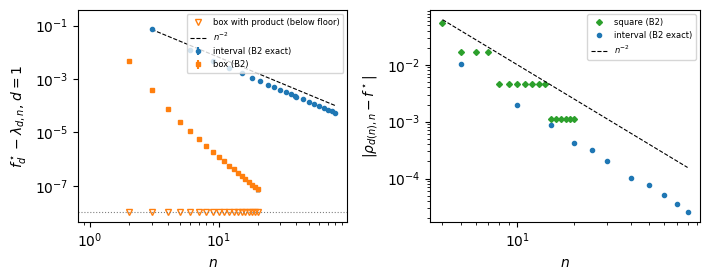

In [18]:
# ---- diagnostic overlay (not a paper figure; nothing is saved): B2 values on top of the R4/B1 brackets
fig, ax = plt.subplots(1, 2, figsize=(7.2, 2.9))
a = ax[0]
for key, v, d, col, mk, lab in [("1d-stengle", "Q", 1, "C0", "o", "interval (B2 exact)"), ("box-edges", "Q", 1, "C1", "s", "box (B2)")]:
    th = sorted((k[3], b) for k, b in CACHE.items() if k[1] == key and k[2] == d and k[4] == v and k[0] in ("R4", "B1") and b[0] > 0)
    a.errorbar([n for n, _ in th], [0.5 * (b[0] + b[1]) for _, b in th],
               yerr=[[0.5 * (b[1] - b[0]) for _, b in th]] * 2, fmt="none", ecolor="0.6", elinewidth=3, alpha=0.6)
    if key == "1d-stengle":
        pts = sorted((n, e) for (dd, n), e in ST.items() if dd == 1)
    else:
        pts = sorted((n, e) for (dd, c, n), e in BOX.items() if dd == 1 and c == "Q")
    a.errorbar([n for n, _ in pts], [0.5 * (e["lo"] + e["hi"]) for _, e in pts],
               yerr=[[0.5 * (e["hi"] - e["lo"]) for _, e in pts]] * 2, fmt=mk, ms=3, color=col, label=lab)
tn = sorted(n for (dd, c, n) in BOX if dd == 1 and c == "T")
a.plot(tn, [FLOOR] * len(tn), "v", mfc="none", color="C1", ms=4, label="box with product (below floor)")
nn = np.array([3, 80.0]); a.plot(nn, ST[(1, 3)]["hi"] * (nn / 3) ** -2.0, "k--", lw=0.8, label=r"$n^{-2}$")
a.axhline(FLOOR, color="0.5", ls=":", lw=0.8)
a.set_xscale("log"); a.set_yscale("log"); a.set_xlabel("$n$"); a.set_ylabel(r"$f^\star_d-\lambda_{d,n}$, $d=1$"); a.legend(fontsize=6)
b = ax[1]
b.plot(list(MIX), [0.5 * (v["lo"] + v["hi"]) for v in MIX.values()], "D", ms=3, color="C2", label="square (B2)")
b.plot(list(STC), [0.5 * (v["lo"] + v["hi"]) for v in STC.values()], "o", ms=3, color="C0", label="interval (B2 exact)")
nn = np.array([4, 80.0]); b.plot(nn, nn ** -2.0, "k--", lw=0.8, label=r"$n^{-2}$")
b.set_xscale("log"); b.set_yscale("log"); b.set_xlabel("$n$"); b.set_ylabel(r"$|\rho_{d(n),n}-f^\star|$"); b.legend(fontsize=6)
fig.tight_layout(); plt.show()

## 8. Summary numbers

In [19]:
# ---- summary numbers for the report
f = FITS
print("interval d=1: slope %.3f on 12..40, %.3f on 20..80 (chord [%.3f, %.3f]), %.3f on 40..80 (chord [%.3f, %.3f])" % (
    f[(1, 12, 40)]["a"], f[(1, 20, 80)]["a"], f[(1, 20, 80)]["chord"][0], f[(1, 20, 80)]["chord"][2],
    f[(1, 40, 80)]["a"], f[(1, 40, 80)]["chord"][0], f[(1, 40, 80)]["chord"][2]))
print("interval d=1: n^2 gap at n=80 %.4f = %.4f range(P_1); d=3: %.4f; d=6: %.4f" % (
    f[(1, 20, 80)]["n2g"], f[(1, 20, 80)]["n2g_range"], f[(3, 18, 80)]["n2g"], f[(6, 18, 80)]["n2g"]))
print("interval exact brackets: %d (d, n) pairs, all verified: %s, widest relative width %.1e" % (
    len(ST), all(e["ok"] for e in ST.values()), max(rw(e["lo"], e["hi"]) for e in ST.values())))
print("box Q d=1: slope %.3f on 4..18, %.3f on 10..18; d=3: %.3f on 4..18" % (BFITS[(1, 4, 18)]["a"], BFITS[(1, 10, 18)]["a"], BFITS[(3, 4, 18)]["a"]))
print("box T: max upper end %.1e (floor %.0e)" % (max(v["hi"] for (d, c, n), v in BOX.items() if c == "T"), FLOOR))
print("sq-mix along d(n): n^2 error in [%.3f, %.3f]; SoS part within [%.1e, %.1e]" % (
    min(n * n * v["lo"] for n, v in MIX.items()), max(n * n * v["hi"] for n, v in MIX.items()),
    min(v["sos_lo"] for v in MIX.values()), max(v["sos_hi"] for v in MIX.values())))
print("interval along d(n): n^2 error in [%.3f, %.3f]" % (min(n * n * v["lo"] for n, v in STC.items()), max(n * n * v["hi"] for n, v in STC.items())))
print("comparisons with R4/B1: %d, overlapping %d" % (len(COMP), sum(c["agree"] for c in COMP)))
print("cvxpy runs: %d; statuses: %s" % (len(CVX), {s: sum(c["status"] == s for c in CVX) for s in sorted(set(c["status"] for c in CVX))}))
print("total run time %.0f s" % (time.time() - T_START))

interval d=1: slope 2.063 on 12..40, 2.032 on 20..80 (chord [2.033, 2.034]), 2.022 on 40..80 (chord [2.022, 2.022])
interval d=1: n^2 gap at n=80 0.3424 = 0.1141 range(P_1); d=3: 0.2121; d=6: 0.2016
interval exact brackets: 43 (d, n) pairs, all verified: True, widest relative width 1.9e-04
box Q d=1: slope 4.286 on 4..18, 4.111 on 10..18; d=3: 4.344 on 4..18
box T: max upper end 9.9e-10 (floor 1e-08)
sq-mix along d(n): n^2 error in [0.247, 0.893]; SoS part within [-4.5e-11, 8.8e-11]
interval along d(n): n^2 error in [0.161, 0.254]
comparisons with R4/B1: 144, overlapping 144
cvxpy runs: 46; statuses: {'error:SolverError': 2, 'optimal': 13, 'optimal_inaccurate': 31}
total run time 2901 s
